# Notebook 10 — Women Final Evaluation

## Purpose

This notebook is the final evaluation notebook for the **women-discourse** experiments.

It is designed to be report-ready and reproducible. It **does not load old metric tables**. Instead, it loads the final test prediction files for each model and recomputes all evaluation metrics from those predictions.

## What this notebook evaluates

### Core metrics promised in the report

- Standard classification metrics: Accuracy and Macro F1
- Distribution metrics: KL divergence, Jensen--Shannon divergence, cross entropy, distribution MAE
- Ordinal metrics: Expected-label MAE and Wasserstein distance
- Uncertainty metrics: entropy MAE and entropy correlations
- Perspectivist evaluation: ANAD against raw annotator labels
- Subgroup evaluation by gender group

### Behavioural analyses for Chapter 4

- Counterfactual subgroup variation
- Polarisation / subgroup-separation index
- Extreme Liberal vs Extreme Conservative analysis
- Human-model disagreement alignment
- Context gain/loss and confidence/entropy shifts
- Qualitative example exports

## Important design note

ANAD is computed from raw annotation labels. For subgroup-conditioned models, the primary ANAD uses raw labels from the corresponding annotator subgroup. For text-only baselines that do not contain subgroup information, ANAD falls back to all annotator labels for the comment.


## 0. Setup

In [1]:
from pathlib import Path
import ast
import itertools
import warnings

import numpy as np
import pandas as pd

from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, pearsonr, spearmanr, wasserstein_distance

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 250)

# ---------------------------------------------------------------------
# Main configuration
# ---------------------------------------------------------------------

DISCOURSE = "women"

RESULTS_DIR = Path("final_evaluation_outputs") / DISCOURSE
TABLES_DIR = RESULTS_DIR / "tables"
PLOTS_DIR = RESULTS_DIR / "plots"
EXAMPLES_DIR = RESULTS_DIR / "examples"

for d in [RESULTS_DIR, TABLES_DIR, PLOTS_DIR, EXAMPLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {
    0: "not_hate_or_neither",
    1: "implicit_or_offensive",
    2: "explicit_hate",
}

NUM_LABELS = 3
MAX_LABEL_DISTANCE = NUM_LABELS - 1

# Women-targeted discourse uses annotator gender as the subgroup dimension.
SUBGROUP_ORDER = [
    "men",
    "women",
    "non_binary",
]

# Focus-pair analysis replaces the focus-pair contrast used in the other discourse notebook.
# For women-targeted discourse, the main contrast is Men vs Women.
FOCUS_LEFT = "men"
FOCUS_RIGHT = "women"
FOCUS_PAIR_NAME = "men_women"
FOCUS_PAIR_LABEL = "Men↔Women"

EPS = 1e-12

print("Results directory:", RESULTS_DIR.resolve())


Results directory: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/final_evaluation_outputs/women


## 1. Data and Model Registry

In [2]:
# ---------------------------------------------------------------------
# Original annotation CSV
# ---------------------------------------------------------------------
# This file has one row per annotation.
# It is used to compute true annotator-aware ANAD.
# Update this path if you run the notebook somewhere else.

ANNOTATION_PATHS = [
    "/home/shayan/Distributional-Hate-Speech-Prediction/data/processed/mhs_main_experiment_annotations_with_split.csv",
    "mhs_main_experiment_annotations_with_split(2).csv",
    "/home/shayan/Distributional-Hate-Speech-Prediction/data/mhs_main_experiment_annotations_with_split.csv",
    "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/mhs_main_experiment_annotations_with_split.csv",
]


def first_existing(paths, recursive_root="."):
    """
    Return the first existing path from a candidate list.

    Candidate entries can be exact paths or glob patterns. Glob patterns are useful
    because the women-discourse models may have slightly different output folder names.
    """
    for p in paths:
        p = str(p)
        if any(ch in p for ch in ["*", "?", "["]):
            matches = sorted(Path(recursive_root).glob(p))
            if matches:
                return matches[0]
        else:
            path = Path(p)
            if path.exists():
                return path
    return None


ANNOTATION_PATH = first_existing(ANNOTATION_PATHS)
print("Annotation path:", ANNOTATION_PATH)


# ---------------------------------------------------------------------
# Model prediction registry
# ---------------------------------------------------------------------
# This notebook only needs prediction files.
# It does NOT load old metric files, old counterfactual files, or old Men/Women files.
#
# If a path is missing, add the correct path below. The notebook recomputes all metrics
# from these prediction files and the raw annotation file.

MODEL_REGISTRY = {
    "Original A": {
        "family": "comment_only",
        "uses_context": False,
        "conditioning": "none",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_original_a_comment_only_outputs/women_original_a_comment_only_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_original_a_comment_only_outputs/women_original_a_comment_only_test_predictions.csv",
            "women_models/women_original_a_comment_only_outputs/women_original_a_comment_only_test_predictions.parquet",
            "women_models/women_original_a_comment_only_outputs/women_original_a_comment_only_test_predictions.csv",
            "women_original_a_comment_only_outputs/women_original_a_comment_only_test_predictions.parquet",
            "women_original_a_comment_only_outputs/women_original_a_comment_only_test_predictions.csv",
            "original_a_comment_only_outputs/original_a_women_test_predictions.parquet",
            "original_a_comment_only_outputs/original_a_women_test_predictions.csv",
            "**/*women*original*a*test_predictions.parquet",
            "**/*women*original*a*test_predictions.csv",
        ],
    },

    "Simple Token": {
        "family": "token",
        "uses_context": False,
        "conditioning": "gender_as_text",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_simple_token_outputs/women_simple_token_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_simple_token_outputs/women_simple_token_test_predictions.csv",
            "women_models/women_simple_token_outputs/women_simple_token_test_predictions.parquet",
            "women_models/women_simple_token_outputs/women_simple_token_test_predictions.csv",
            "simple_token_outputs/women_simple_token_test_predictions.parquet",
            "simple_token_outputs/women_simple_token_test_predictions.csv",
            "token_outputs/women_token_test_predictions.parquet",
            "token_outputs/women_token_test_predictions.csv",
            "subgroup_baseline_outputs/women_subgroup_baseline_test_predictions.parquet",
            "subgroup_baseline_outputs/women_subgroup_baseline_test_predictions.csv",
            "**/*women*token*test_predictions.parquet",
            "**/*women*token*test_predictions.csv",
        ],
    },

    "Embedding": {
        "family": "embedding",
        "uses_context": False,
        "conditioning": "gender_embedding",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_subgroup_embedding_outputs/women_subgroup_embedding_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_subgroup_embedding_outputs/women_subgroup_embedding_test_predictions.csv",
            "women_models/women_subgroup_embedding_outputs/women_subgroup_embedding_test_predictions.parquet",
            "women_models/women_subgroup_embedding_outputs/women_subgroup_embedding_test_predictions.csv",
            "subgroup_embedding_outputs/women_subgroup_embedding_test_predictions.parquet",
            "subgroup_embedding_outputs/women_subgroup_embedding_test_predictions.csv",
            "**/*women*embedding*test_predictions.parquet",
            "**/*women*embedding*test_predictions.csv",
        ],
    },

    "Strong FiLM": {
        "family": "film",
        "uses_context": False,
        "conditioning": "film_gender_modulation",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_film_outputs/women_film_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_film_outputs/women_film_test_predictions.csv",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_film_outputs/women_film_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_film_outputs/women_film_test_predictions.csv",
            "women_models/women_film_outputs/women_film_test_predictions.parquet",
            "women_models/women_film_outputs/women_film_test_predictions.csv",
            "boostedfilm_outputs/women_film_test_predictions.parquet",
            "boostedfilm_outputs/women_film_test_predictions.csv",
            "film_outputs/women_film_test_predictions.parquet",
            "film_outputs/women_film_test_predictions.csv",
            "**/*women*film*test_predictions.parquet",
            "**/*women*film*test_predictions.csv",
        ],
    },

    "Context + Token": {
        "family": "context_token",
        "uses_context": True,
        "conditioning": "context_and_gender_as_text",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_token_women_outputs/context_token_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_token_women_outputs/context_token_test_predictions.csv",
            "women_models/women_context_token_outputs/women_context_token_test_predictions.parquet",
            "women_models/women_context_token_outputs/women_context_token_test_predictions.csv",
            "women_models/context_token_outputs/women_context_token_test_predictions.parquet",
            "women_models/context_token_outputs/women_context_token_test_predictions.csv",
            "**/*women*context*token*test_predictions.parquet",
            "**/*women*context*token*test_predictions.csv",
        ],
    },

    "Context + Embedding": {
        "family": "context_embedding",
        "uses_context": True,
        "conditioning": "context_text_plus_gender_embedding",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_embedding_women_outputs/context_embedding_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_embedding_women_outputs/context_embedding_test_predictions.csv",
            "women_models/women_context_embedding_outputs/women_context_embedding_test_predictions.parquet",
            "women_models/women_context_embedding_outputs/women_context_embedding_test_predictions.csv",
            "women_models/context_embedding_outputs/women_context_embedding_test_predictions.parquet",
            "women_models/context_embedding_outputs/women_context_embedding_test_predictions.csv",
            "**/*women*context*embedding*test_predictions.parquet",
            "**/*women*context*embedding*test_predictions.csv",
        ],
    },

    "Context + Strong FiLM": {
        "family": "context_film",
        "uses_context": True,
        "conditioning": "context_text_plus_film_gender_modulation",
        "prediction_paths": [
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_strong_film_outputs/context_strong_film_test_predictions.parquet",
            "/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_strong_film_outputs/context_strong_film_test_predictions.csv",
            "women_models/women_context_strong_film_outputs/women_context_strong_film_test_predictions.parquet",
            "women_models/women_context_strong_film_outputs/women_context_strong_film_test_predictions.csv",
            "women_models/context_strong_film_outputs/women_context_strong_film_test_predictions.parquet",
            "women_models/context_strong_film_outputs/women_context_strong_film_test_predictions.csv",
            "**/*women*context*film*test_predictions.parquet",
            "**/*women*context*film*test_predictions.csv",
        ],
    },
}


audit_rows = []
for model_name, cfg in MODEL_REGISTRY.items():
    pred_path = first_existing(cfg["prediction_paths"])
    audit_rows.append({
        "model": model_name,
        "family": cfg["family"],
        "uses_context": cfg["uses_context"],
        "conditioning": cfg["conditioning"],
        "prediction_file": str(pred_path) if pred_path else None,
        "status": "prediction_file_found" if pred_path else "missing_prediction_file",
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

audit_df.to_csv(TABLES_DIR / "model_prediction_file_audit.csv", index=False)
print("Saved:", TABLES_DIR / "model_prediction_file_audit.csv")


Annotation path: /home/shayan/Distributional-Hate-Speech-Prediction/data/processed/mhs_main_experiment_annotations_with_split.csv


,model,family,uses_context,conditioning,prediction_file,status
0,Original A,comment_only,False,none,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_original_a_comment_only_outputs/women_original_a_comment_only_test_predictions.parquet,prediction_file_found
1,Simple Token,token,False,gender_as_text,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_simple_token_outputs/women_simple_token_test_predictions.parquet,prediction_file_found
2,Embedding,embedding,False,gender_embedding,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_subgroup_embedding_outputs/women_subgroup_embedding_test_predictions.parquet,prediction_file_found
3,Strong FiLM,film,False,film_gender_modulation,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_film_outputs/women_film_test_predictions.parquet,prediction_file_found
4,Context + Token,context_token,True,context_and_gender_as_text,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_token_women_outputs/context_token_test_predictions.parquet,prediction_file_found
5,Context + Embedding,context_embedding,True,context_text_plus_gender_embedding,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_embedding_women_outputs/context_embedding_test_predictions.parquet,prediction_file_found
6,Context + Strong FiLM,context_film,True,context_text_plus_film_gender_modulation,/home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_strong_film_outputs/context_strong_film_test_predictions.parquet,prediction_file_found


Saved: final_evaluation_outputs/women/tables/model_prediction_file_audit.csv


## 2. Load Original Annotations and Build Raw Label Vectors

In [3]:
if ANNOTATION_PATH is None:
    raise FileNotFoundError(
        "Could not find annotation CSV. Update ANNOTATION_PATHS in the registry cell."
    )

annotations = pd.read_csv(ANNOTATION_PATH)

print("Annotation columns:")
print(annotations.columns.tolist())

display(annotations.head())


def find_column(df, candidates, required=True):
    """Return the first available column from a list of candidate names."""
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise ValueError(f"Could not find any of these columns: {candidates}")
    return None


# ---------------------------------------------------------------------
# Identify required columns.
# ---------------------------------------------------------------------
# The aliases below make this notebook robust to small naming differences between
# preprocessing runs.

COMMENT_ID_COL = find_column(annotations, ["comment_id", "id", "comment_id_original"])
LABEL_COL = find_column(annotations, ["hatespeech", "label", "hate_speech_label", "final_label"])
SPLIT_COL = find_column(annotations, ["split", "data_split"])
TARGET_TYPE_COL = find_column(annotations, ["target_type", "target", "discourse", "target_group"])
GENDER_COL = find_column(
    annotations,
    [
        "annotator_gender",
        "annotator_gender_group",
        "gender",
        "gender_identity",
        "annotator_gender_identity",
    ],
)

print("Using columns:")
print({
    "comment_id": COMMENT_ID_COL,
    "label": LABEL_COL,
    "split": SPLIT_COL,
    "target_type": TARGET_TYPE_COL,
    "subgroup_gender": GENDER_COL,
})


# ---------------------------------------------------------------------
# Filter to women-targeted test annotations.
# ---------------------------------------------------------------------
# We keep target_type values containing women/woman/female/gender or both.
# If your target_type names differ, inspect the printed unique values below.

print("\nTarget types:")
print(annotations[TARGET_TYPE_COL].value_counts(dropna=False))

print("\nSplits:")
print(annotations[SPLIT_COL].value_counts(dropna=False))

women_mask = (
    annotations[TARGET_TYPE_COL]
    .astype(str)
    .str.lower()
    .str.contains("women|woman|female|gender|both", regex=True)
)

test_mask = annotations[SPLIT_COL].astype(str).str.lower().eq("test")

women_test_annotations = annotations[
    women_mask & test_mask
].copy()

women_test_annotations = women_test_annotations.dropna(subset=[COMMENT_ID_COL, LABEL_COL])
women_test_annotations[LABEL_COL] = women_test_annotations[LABEL_COL].astype(int)
women_test_annotations[GENDER_COL] = women_test_annotations[GENDER_COL].apply(lambda x: str(x).strip().lower().replace(" ", "_").replace("-", "_"))

# Normalize common gender labels so they match prediction files.
gender_aliases = {
    "male": "men",
    "man": "men",
    "men": "men",
    "female": "women",
    "woman": "women",
    "women": "women",
    "nonbinary": "non_binary",
    "non_binary": "non_binary",
    "non-binary": "non_binary",
    "non_binary_gender": "non_binary",
    "prefer_not_to_say": "prefer_not_to_say",
    "self_describe": "self_describe",
    "nan": "unknown",
    "none": "unknown",
}
women_test_annotations[GENDER_COL] = women_test_annotations[GENDER_COL].map(
    lambda x: gender_aliases.get(x, x)
)

# The experimental women discourse models use men, women and non_binary.
# Keep the other labels in the raw file only if your prediction files contain them.
VALID_GENDER_SUBGROUPS = set(SUBGROUP_ORDER)
women_test_annotations = women_test_annotations[
    women_test_annotations[GENDER_COL].isin(VALID_GENDER_SUBGROUPS)
].copy()

print("\nWomen test annotation rows:", len(women_test_annotations))
print("Unique test comments:", women_test_annotations[COMMENT_ID_COL].nunique())
print("\nGender subgroup counts:")
print(women_test_annotations[GENDER_COL].value_counts(dropna=False))

display(women_test_annotations.head())


# ---------------------------------------------------------------------
# Build raw annotator label vectors per comment.
# ---------------------------------------------------------------------

raw_label_vectors_by_comment = (
    women_test_annotations
    .groupby(COMMENT_ID_COL)[LABEL_COL]
    .apply(lambda x: x.astype(int).tolist())
    .to_dict()
)

# Subgroup-specific raw label vectors for ANAD.
raw_label_vectors_by_comment_subgroup = (
    women_test_annotations
    .dropna(subset=[GENDER_COL])
    .groupby([COMMENT_ID_COL, GENDER_COL])[LABEL_COL]
    .apply(lambda x: x.astype(int).tolist())
    .to_dict()
)

print("Raw label vectors available for comments:", len(raw_label_vectors_by_comment))
print("Raw label vectors available for comment–gender subgroup pairs:", len(raw_label_vectors_by_comment_subgroup))


Annotation columns:
['comment_id', 'annotator_id', 'sentiment', 'respect', 'insult', 'humiliate', 'status', 'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech', 'annotator_gender', 'annotator_trans', 'annotator_gender_men', 'annotator_gender_women', 'annotator_gender_non_binary', 'annotator_gender_prefer_not_to_say', 'annotator_gender_self_describe', 'annotator_transgender', 'annotator_cisgender', 'annotator_transgender_prefer_not_to_say', 'annotator_ideology', 'annotator_ideology_extremeley_conservative', 'annotator_ideology_conservative', 'annotator_ideology_slightly_conservative', 'annotator_ideology_neutral', 'annotator_ideology_slightly_liberal', 'annotator_ideology_liberal', 'annotator_ideology_extremeley_liberal', 'annotator_ideology_no_opinion', 'target_gender', 'target_gender_men', 'target_gender_non_binary', 'target_gender_transgender_men', 'target_gender_transgender_unspecified', 'target_gender_transgender_women', 'target_gender_women', 'target_gender_other',

,comment_id,annotator_id,sentiment,respect,insult,humiliate,status,dehumanize,violence,genocide,attack_defend,hatespeech,annotator_gender,annotator_trans,annotator_gender_men,annotator_gender_women,annotator_gender_non_binary,annotator_gender_prefer_not_to_say,annotator_gender_self_describe,annotator_transgender,annotator_cisgender,annotator_transgender_prefer_not_to_say,annotator_ideology,annotator_ideology_extremeley_conservative,annotator_ideology_conservative,annotator_ideology_slightly_conservative,annotator_ideology_neutral,annotator_ideology_slightly_liberal,annotator_ideology_liberal,annotator_ideology_extremeley_liberal,annotator_ideology_no_opinion,target_gender,target_gender_men,target_gender_non_binary,target_gender_transgender_men,target_gender_transgender_unspecified,target_gender_transgender_women,target_gender_women,target_gender_other,target_origin,target_origin_immigrant,target_origin_migrant_worker,target_origin_specific_country,target_origin_undocumented,target_origin_other,text_original,text_clean,is_women_targeted,is_immigrant_targeted,annotator_gender_group,annotator_ideology_group,target_type,split
0,47101,3379,4.0,4.0,4.0,4.0,4.0,4.0,0.0,0.0,4.0,2.0,male,no,1,0,0,0,0,False,True,False,slightly_conservative,0,0,1,0,0,0,0,0,False,0,0,0,0,0,0,0,True,1,0,0,0,0,"Question: These 4 broads who criticize America, what country did they flee to get here? And now they want to make OUR America like THEIR former HELL HOLE. I don't think so!!!!!!!!!! Let them explain their GRATITUDE for letting them in OUR country.","Question: These 4 broads who criticize America, what country did they flee to get here? And now they want to make OUR America like THEIR former HELL HOLE. I don't think so!!!!!!!!!! Let them explain their GRATITUDE for letting them in OUR country.",0,1,men,slightly_conservative,immigrant_only,validation
1,43625,7365,2.0,3.0,2.0,1.0,2.0,0.0,0.0,0.0,3.0,0.0,male,no,1,0,0,0,0,False,True,False,neutral,0,0,0,1,0,0,0,0,False,0,0,0,0,0,0,0,True,0,0,0,1,0,It is about time for all illegals to go back to their country of origin and keep our freeway open and prevent heavy traffic.,It is about time for all illegals to go back to their country of origin and keep our freeway open and prevent heavy traffic.,0,1,men,neutral,immigrant_only,train
2,12538,488,4.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,3.0,2.0,female,no,0,1,0,0,0,False,True,False,neutral,0,0,0,1,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,1,0,women,neutral,women_only,test
3,40171,10363,4.0,4.0,4.0,3.0,3.0,3.0,0.0,1.0,1.0,0.0,female,no,0,1,0,0,0,False,True,False,slightly_conservative,0,0,1,0,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,"OMG! The EGO's of these young, young, inexperienced women display are remarkable! So self absorbed - so, so proud of the mistakes their constituents all made in giving them a bit of power. They'll be quite surprised to find that the vast majorit...","OMG! The EGO's of these young, young, inexperienced women display are remarkable! So self absorbed - so, so proud of the mistakes their constituents all made in giving them a bit of power. They'll be quite surprised to find that the vast majority...",1,0,women,slightly_conservative,women_only,train
4,1006,10615,4.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,4.0,2.0,female,no,0,1,0,0,0,False,True,False,extremely_liberal,0,0,0,0,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,"Worthless whore, these tits with look nice with bite marks and cum","Worthless whore, these tits with look nice with bite marks and cum",1,0,women,extremely_liberal,women_only,train


Using columns:
{'comment_id': 'comment_id', 'label': 'hatespeech', 'split': 'split', 'target_type': 'target_type', 'subgroup_gender': 'annotator_gender'}

Target types:
target_type
women_only             26905
immigrant_only         21544
women_and_immigrant      984
Name: count, dtype: int64

Splits:
split
train         34413
test           7713
validation     7307
Name: count, dtype: int64

Women test annotation rows: 4747
Unique test comments: 1793

Gender subgroup counts:
annotator_gender
women         2698
men           2021
non_binary      28
Name: count, dtype: int64


,comment_id,annotator_id,sentiment,respect,insult,humiliate,status,dehumanize,violence,genocide,attack_defend,hatespeech,annotator_gender,annotator_trans,annotator_gender_men,annotator_gender_women,annotator_gender_non_binary,annotator_gender_prefer_not_to_say,annotator_gender_self_describe,annotator_transgender,annotator_cisgender,annotator_transgender_prefer_not_to_say,annotator_ideology,annotator_ideology_extremeley_conservative,annotator_ideology_conservative,annotator_ideology_slightly_conservative,annotator_ideology_neutral,annotator_ideology_slightly_liberal,annotator_ideology_liberal,annotator_ideology_extremeley_liberal,annotator_ideology_no_opinion,target_gender,target_gender_men,target_gender_non_binary,target_gender_transgender_men,target_gender_transgender_unspecified,target_gender_transgender_women,target_gender_women,target_gender_other,target_origin,target_origin_immigrant,target_origin_migrant_worker,target_origin_specific_country,target_origin_undocumented,target_origin_other,text_original,text_clean,is_women_targeted,is_immigrant_targeted,annotator_gender_group,annotator_ideology_group,target_type,split
2,12538,488,4.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,3.0,2,women,no,0,1,0,0,0,False,True,False,neutral,0,0,0,1,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,1,0,women,neutral,women_only,test
12,1323,2017,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0,women,no,0,1,0,0,0,False,True,False,extremely_liberal,0,0,0,0,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,"Thank you for posting this! Gives us other ""normal"" women confidence. We all aren't skinny, or shaved, of perky. Doesn't mean we still aren't sexy.","Thank you for posting this! Gives us other ""normal"" women confidence. We all aren't skinny, or shaved, of perky. Doesn't mean we still aren't sexy.",1,0,women,extremely_liberal,women_only,test
13,38126,6701,4.0,3.0,3.0,3.0,2.0,0.0,0.0,0.0,3.0,1,women,no,0,1,0,0,0,False,True,False,conservative,0,1,0,0,0,0,0,0,True,1,0,0,0,0,1,0,False,0,0,0,0,0,"Y'all always slip up and say how y'all see women period because this includes the majority of women in yall lives that's not related to you. Especially since men demand pussy just from taking you out, selling you weed or even being nice to you. N...","Y'all always slip up and say how y'all see women period because this includes the majority of women in yall lives that's not related to you. Especially since men demand pussy just from taking you out, selling you weed or even being nice to you. N...",1,0,women,conservative,women_only,test
15,32811,3540,3.0,3.0,3.0,2.0,2.0,3.0,0.0,0.0,2.0,0,men,no,1,0,0,0,0,False,True,False,neutral,0,0,0,1,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,"Cold hoe that's a must, bitch body A plus, bitch pussy A1","Cold hoe that's a must, bitch body A plus, bitch pussy A1",1,0,men,neutral,women_only,test
41,5650,1742,3.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0,men,no,1,0,0,0,0,False,True,False,conservative,0,1,0,0,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,Was she a former prostitute that Richard Gere was making into a lady?,Was she a former prostitute that Richard Gere was making into a lady?,1,0,men,conservative,women_only,test


Raw label vectors available for comments: 1793
Raw label vectors available for comment–gender subgroup pairs: 2384


## 3. Metric Functions

In [9]:
def parse_distribution(value):
    """Parse a distribution stored as ndarray, list, tuple, or string."""
    if isinstance(value, np.ndarray):
        return value.astype(float)
    if isinstance(value, list):
        return np.array(value, dtype=float)
    if isinstance(value, tuple):
        return np.array(value, dtype=float)
    if isinstance(value, str):
        value = value.strip()
        try:
            return np.array(ast.literal_eval(value), dtype=float)
        except Exception:
            cleaned = value.strip("[]").replace(",", " ")
            return np.array([float(x) for x in cleaned.split()], dtype=float)
    raise TypeError(f"Unsupported distribution type: {type(value)}")


def normalize_distribution(x):
    """Ensure vector is a valid probability distribution."""
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0, None)
    total = x.sum()
    if total <= 0:
        return np.ones_like(x) / len(x)
    return x / total


def stack_distributions(series):
    """Convert a dataframe column of distributions into a 2D numpy array."""
    return np.vstack(series.apply(parse_distribution).apply(normalize_distribution).to_numpy())


def kl_divergence(y_true, y_pred):
    y_true = np.clip(y_true, EPS, 1.0)
    y_pred = np.clip(y_pred, EPS, 1.0)
    y_true = y_true / y_true.sum(axis=1, keepdims=True)
    y_pred = y_pred / y_pred.sum(axis=1, keepdims=True)
    return np.sum(y_true * np.log(y_true / y_pred), axis=1)


def js_divergence(y_true, y_pred):
    return np.array([
        jensenshannon(normalize_distribution(t), normalize_distribution(p), base=2) ** 2
        for t, p in zip(y_true, y_pred)
    ])


def cross_entropy(y_true, y_pred):
    y_true = np.clip(y_true, EPS, 1.0)
    y_pred = np.clip(y_pred, EPS, 1.0)
    y_true = y_true / y_true.sum(axis=1, keepdims=True)
    y_pred = y_pred / y_pred.sum(axis=1, keepdims=True)
    return -np.sum(y_true * np.log(y_pred), axis=1)


def distribution_mae(y_true, y_pred):
    """Mean absolute error over distribution probabilities."""
    return np.mean(np.abs(y_true - y_pred), axis=1)


def expected_scores(distributions):
    return distributions @ np.arange(distributions.shape[1])


def entropy_values(distributions):
    return np.array([entropy(normalize_distribution(d), base=2) for d in distributions])


def average_MD(targets, predictions):
    """Average Manhattan Distance between target and predicted distributions."""
    return float(np.mean(np.sum(np.abs(predictions - targets), axis=1)))


def average_wasserstein(y_true, y_pred):
    """Ordinal Wasserstein distance over label positions."""
    positions = np.arange(y_true.shape[1])
    distances = []
    for true, pred in zip(y_true, y_pred):
        distances.append(
            wasserstein_distance(
                positions,
                positions,
                u_weights=normalize_distribution(true),
                v_weights=normalize_distribution(pred),
            )
        )
    return float(np.mean(distances)) if distances else np.nan


def anad_from_labels(pred_dist, raw_labels, max_label_distance=MAX_LABEL_DISTANCE, prediction_mode="argmax"):
    """
    Average Normalized Absolute Distance for one prediction row.

    This follows the LeWiDi-style ordinal evaluation idea: compare a model-predicted
    ordinal label against each raw annotator label for the same instance, normalize by
    the label range, then average.

    prediction_mode="argmax" is the primary report setting because ANAD is defined
    over predicted labels. prediction_mode="expected" is retained only for optional
    sensitivity analysis.
    """
    pred_dist = normalize_distribution(pred_dist)

    if raw_labels is None or len(raw_labels) == 0:
        return np.nan

    if prediction_mode == "argmax":
        pred_label = int(np.argmax(pred_dist))
    elif prediction_mode == "expected":
        pred_label = float(np.sum(pred_dist * np.arange(len(pred_dist))))
    else:
        raise ValueError("prediction_mode must be 'argmax' or 'expected'")

    distances = [
        abs(float(label) - pred_label) / max_label_distance
        for label in raw_labels
    ]

    return float(np.mean(distances) * 100)


def safe_js(a, b):
    return float(
        jensenshannon(
            normalize_distribution(a),
            normalize_distribution(b),
            base=2,
        ) ** 2
    )


def compute_anad_for_dataframe(df, label_vector_lookup, use_subgroup=False, prediction_mode="argmax"):
    """
    Compute ANAD for each prediction row.

    If use_subgroup=True, labels are looked up using (comment_id, subgroup).
    Otherwise, all raw labels for the comment are used.
    """
    values = []

    for _, row in df.iterrows():
        pred = parse_distribution(row["pred_distribution"])

        if use_subgroup:
            key = (row["comment_id"], row["subgroup"])
            raw_labels = label_vector_lookup.get(key, None)
        else:
            raw_labels = label_vector_lookup.get(row["comment_id"], None)

        values.append(anad_from_labels(pred, raw_labels, prediction_mode=prediction_mode))

    return np.array(values, dtype=float)


def choose_primary_anad(df):
    """
    Primary ANAD used in report tables.

    For subgroup-conditioned rows where subgroup-specific raw labels exist, use subgroup ANAD.
    Otherwise fall back to comment-level ANAD. This keeps Original A evaluable while making
    identity-conditioned models genuinely subgroup-aware.
    """
    if "anad_subgroup_argmax" in df.columns and df["anad_subgroup_argmax"].notna().any():
        return df["anad_subgroup_argmax"].where(
            df["anad_subgroup_argmax"].notna(),
            df["anad_comment_argmax"],
        )
    return df["anad_comment_argmax"]


def compute_distribution_metrics(y_true, y_pred, anad_values=None):
    """Compute report-ready predictive, distributional, uncertainty and ANAD metrics."""
    true_labels = np.argmax(y_true, axis=1)
    pred_labels = np.argmax(y_pred, axis=1)

    true_ent = entropy_values(y_true)
    pred_ent = entropy_values(y_pred)

    entropy_abs_error = np.abs(true_ent - pred_ent)

    metrics = {
        "n": len(y_true),
        "kl_mean": float(kl_divergence(y_true, y_pred).mean()),
        "js_mean": float(js_divergence(y_true, y_pred).mean()),
        "cross_entropy_mean": float(cross_entropy(y_true, y_pred).mean()),
        "distribution_mae_mean": float(distribution_mae(y_true, y_pred).mean()),
        "accuracy": float(accuracy_score(true_labels, pred_labels)),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro", zero_division=0)),
        "expected_label_mae": float(mean_absolute_error(expected_scores(y_true), expected_scores(y_pred))),
        "distribution_average_MD": average_MD(y_true, y_pred),
        "average_wasserstein": average_wasserstein(y_true, y_pred),
        "mean_true_entropy": float(true_ent.mean()),
        "mean_pred_entropy": float(pred_ent.mean()),
        "entropy_mae": float(entropy_abs_error.mean()),
        "entropy_median_abs_error": float(np.median(entropy_abs_error)),
    }

    if anad_values is not None:
        metrics["anad_mean"] = float(np.nanmean(anad_values))
        metrics["anad_median"] = float(np.nanmedian(anad_values))
        metrics["anad_coverage"] = float(np.mean(~np.isnan(anad_values)))
    else:
        metrics["anad_mean"] = np.nan
        metrics["anad_median"] = np.nan
        metrics["anad_coverage"] = np.nan

    if len(np.unique(true_ent)) > 1 and len(np.unique(pred_ent)) > 1:
        metrics["entropy_pearson"] = float(pearsonr(true_ent, pred_ent).statistic)
        metrics["entropy_spearman"] = float(spearmanr(true_ent, pred_ent).statistic)
    else:
        metrics["entropy_pearson"] = np.nan
        metrics["entropy_spearman"] = np.nan

    return metrics


## 4. Load and Standardize Test Predictions

In [23]:
def read_prediction_file(path):
    path = Path(path)
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported prediction file type: {path}")


def standardize_subgroup(value):
    if pd.isna(value):
        return "unknown"
    s = str(value).strip().lower()
    s = s.replace(" ", "_").replace("-", "_")

    aliases = {
        "male": "men",
        "man": "men",
        "men": "men",
        "female": "women",
        "woman": "women",
        "women": "women",
        "nonbinary": "non_binary",
        "non_binary": "non_binary",
        "non_binary_gender": "non_binary",
        "prefer_not_to_say": "prefer_not_to_say",
        "self_describe": "self_describe",
        "none": "unknown",
        "nan": "unknown",
    }
    return aliases.get(s, s)


def standardize_predictions(df, model_name, cfg):
    df = df.copy()

    if "true_distribution" not in df.columns:
        if "target_distribution" in df.columns:
            df["true_distribution"] = df["target_distribution"]
        else:
            raise ValueError(f"{model_name}: missing true_distribution or target_distribution")

    if "pred_distribution" not in df.columns:
        raise ValueError(f"{model_name}: missing pred_distribution")

    if "text" not in df.columns:
        for alt in ["comment", "tweet", "comment_text", "clean_text", "text_clean"]:
            if alt in df.columns:
                df["text"] = df[alt]
                break
    if "text" not in df.columns:
        df["text"] = ""

    if "comment_id" not in df.columns:
        if "id" in df.columns:
            df["comment_id"] = df["id"]
        else:
            raise ValueError(
                f"{model_name}: missing comment_id. Do not create row-number IDs because ANAD and matched context analysis need real comment IDs."
            )

    if "subgroup" not in df.columns:
        for alt in [
            "annotator_gender",
            "annotator_gender_group",
            "gender",
            "gender_identity",
            "annotator_gender_identity",
            "group",
            "subgroup_name",
        ]:
            if alt in df.columns:
                df["subgroup"] = df[alt]
                break
    if "subgroup" not in df.columns:
        df["subgroup"] = "unknown"

    df["subgroup"] = df["subgroup"].apply(standardize_subgroup)

    y_true = stack_distributions(df["true_distribution"])
    y_pred = stack_distributions(df["pred_distribution"])

    if "target_majority_label" not in df.columns:
        df["target_majority_label"] = np.argmax(y_true, axis=1)

    df["pred_majority_label"] = np.argmax(y_pred, axis=1)

    df["true_expected_label"] = expected_scores(y_true)
    df["pred_expected_label"] = expected_scores(y_pred)

    df["true_entropy"] = entropy_values(y_true)
    df["pred_entropy"] = entropy_values(y_pred)
    df["entropy_abs_error"] = np.abs(df["true_entropy"] - df["pred_entropy"])

    df["kl"] = kl_divergence(y_true, y_pred)
    df["js"] = js_divergence(y_true, y_pred)
    df["cross_entropy"] = cross_entropy(y_true, y_pred)
    df["distribution_mae"] = distribution_mae(y_true, y_pred)
    df["abs_expected_error"] = np.abs(df["true_expected_label"] - df["pred_expected_label"])

    # ANAD against all labels for the comment. Useful for Original A and as a fallback.
    df["anad_comment_argmax"] = compute_anad_for_dataframe(
        df,
        raw_label_vectors_by_comment,
        use_subgroup=False,
        prediction_mode="argmax",
    )

    # True subgroup-aware ANAD: predicted label is compared only against raw annotator labels
    # from the same gender subgroup.
    df["anad_subgroup_argmax"] = compute_anad_for_dataframe(
        df,
        raw_label_vectors_by_comment_subgroup,
        use_subgroup=True,
        prediction_mode="argmax",
    )

    df["true_anad"] = choose_primary_anad(df)
    df["anad_eval"] = df["true_anad"]
    df["true_anad_subgroup"] = df["anad_subgroup_argmax"]
    # Keep an expected-label sensitivity version for optional appendix checks.
    df["anad_comment_expected"] = compute_anad_for_dataframe(
        df,
        raw_label_vectors_by_comment,
        use_subgroup=False,
        prediction_mode="expected",
    )
    df["anad_subgroup_expected"] = compute_anad_for_dataframe(
        df,
        raw_label_vectors_by_comment_subgroup,
        use_subgroup=True,
        prediction_mode="expected",
    )

    df["model"] = model_name
    df["family"] = cfg["family"]
    df["uses_context"] = cfg["uses_context"]
    df["conditioning"] = cfg["conditioning"]

    return df


predictions_by_model = {}

for model_name, cfg in MODEL_REGISTRY.items():
    pred_path = first_existing(cfg["prediction_paths"])

    if pred_path is None:
        print(f"[missing] {model_name}")
        continue

    print(f"[loading] {model_name}: {pred_path}")
    raw_df = read_prediction_file(pred_path)
    std_df = standardize_predictions(raw_df, model_name, cfg)
    predictions_by_model[model_name] = std_df

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    std_df.to_csv(TABLES_DIR / f"{safe_name}_standardized_predictions.csv", index=False)

print("\nLoaded models:", list(predictions_by_model.keys()))

if not predictions_by_model:
    raise RuntimeError("No model predictions were loaded. Check MODEL_REGISTRY paths.")

for model_name, df in predictions_by_model.items():
    print(model_name, df.shape, df["subgroup"].value_counts(dropna=False).to_dict())


[loading] Original A: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_original_a_comment_only_outputs/women_original_a_comment_only_test_predictions.parquet
[loading] Simple Token: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_simple_token_outputs/women_simple_token_test_predictions.parquet
[loading] Embedding: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_subgroup_embedding_outputs/women_subgroup_embedding_test_predictions.parquet
[loading] Strong FiLM: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/women_film_outputs/women_film_test_predictions.parquet
[loading] Context + Token: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_token_women_outputs/context_token_test_predictions.parquet
[loading] Context + Embedding: /home/shayan/Distributional-Hate-Speech-Prediction/notebooks/women_models/context_embedding_women_outputs/context

## 5. Overall Report Metrics

In [13]:
master_rows = []

for model_name, df in predictions_by_model.items():
    y_true = stack_distributions(df["true_distribution"])
    y_pred = stack_distributions(df["pred_distribution"])

    master_rows.append({
        "model": model_name,
        "family": MODEL_REGISTRY[model_name]["family"],
        "conditioning": MODEL_REGISTRY[model_name]["conditioning"],
        "uses_context": MODEL_REGISTRY[model_name]["uses_context"],
        **compute_distribution_metrics(y_true, y_pred, anad_values=df["anad_eval"].to_numpy()),
        "anad_subgroup_coverage": float(df["anad_subgroup_argmax"].notna().mean()),
    })

master_metrics_df = pd.DataFrame(master_rows).sort_values("kl_mean")
display(master_metrics_df)

master_metrics_df.to_csv(TABLES_DIR / "master_predictive_metrics.csv", index=False)
print("Saved:", TABLES_DIR / "master_predictive_metrics.csv")


,model,family,conditioning,uses_context,n,kl_mean,js_mean,cross_entropy_mean,distribution_mae_mean,accuracy,macro_f1,expected_label_mae,distribution_average_MD,average_wasserstein,mean_true_entropy,mean_pred_entropy,entropy_mae,entropy_median_abs_error,anad_mean,anad_median,anad_coverage,entropy_pearson,entropy_spearman,anad_subgroup_coverage
2,Embedding,embedding,gender_embedding,False,1173,0.660664,0.241478,0.744127,0.236024,0.705882,0.460117,0.551171,0.708071,0.580702,0.120412,0.869675,0.784499,0.831851,25.969483,0.0,1.0,0.136880,0.129569,1.0
1,Simple Token,token,gender_as_text,False,1173,0.665467,0.259294,0.748931,0.258587,0.694800,0.454070,0.582427,0.775762,0.610560,0.120412,1.038095,0.942602,1.018009,27.013814,0.0,1.0,0.113414,0.113130,1.0
0,Original A,comment_only,none,False,1173,0.672379,0.241955,0.755842,0.233916,0.701620,0.460010,0.551704,0.701749,0.578738,0.120412,0.834742,0.754475,0.710816,26.480992,0.0,1.0,0.138300,0.137102,1.0
4,Context + Token,context_token,context_and_gender_as_text,True,1173,0.679814,0.243703,0.763277,0.235576,0.697357,0.458810,0.559666,0.706728,0.586552,0.120412,0.842520,0.763420,0.689772,26.608870,0.0,1.0,0.134485,0.120518,1.0
5,Context + Embedding,context_embedding,context_text_plus_gender_embedding,True,1173,0.689133,0.247376,0.772596,0.239720,0.695652,0.460131,0.560432,0.719161,0.586165,0.120412,0.863508,0.785697,0.779824,26.765164,0.0,1.0,0.115072,0.101084,1.0
3,Strong FiLM,film,film_gender_modulation,False,1173,0.692755,0.243159,0.776218,0.232976,0.710145,0.465231,0.548156,0.698929,0.574906,0.120412,0.822072,0.748929,0.629357,25.727938,0.0,1.0,0.137086,0.127451,1.0
6,Context + Strong FiLM,context_film,context_text_plus_film_gender_modulation,True,1173,0.719503,0.244934,0.802966,0.231794,0.702472,0.458404,0.540895,0.695382,0.562956,0.120412,0.783496,0.719219,0.618153,26.658600,0.0,1.0,0.118648,0.117159,1.0


Saved: final_evaluation_outputs/women/tables/master_predictive_metrics.csv


## 6. Confusion Matrices and Classification Reports

In [14]:
for model_name, df in predictions_by_model.items():
    y_true = stack_distributions(df["true_distribution"])
    y_pred = stack_distributions(df["pred_distribution"])

    true_labels = np.argmax(y_true, axis=1)
    pred_labels = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(true_labels, pred_labels, labels=[0, 1, 2])
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{i}" for i in [0, 1, 2]],
        columns=[f"pred_{i}" for i in [0, 1, 2]],
    )

    report = classification_report(
        true_labels,
        pred_labels,
        labels=[0, 1, 2],
        zero_division=0,
        output_dict=True,
    )
    report_df = pd.DataFrame(report).T

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    cm_df.to_csv(TABLES_DIR / f"{safe_name}_confusion_matrix.csv")
    report_df.to_csv(TABLES_DIR / f"{safe_name}_classification_report.csv")

    print("=" * 100)
    print(model_name)
    display(cm_df)
    display(report_df)


Original A


,pred_0,pred_1,pred_2
true_0,613,0,172
true_1,52,0,34
true_2,92,0,210


,precision,recall,f1-score,support
0,0.809775,0.780892,0.795071,785.00000
1,0.000000,0.000000,0.000000,86.00000
2,0.504808,0.695364,0.584958,302.00000
accuracy,0.701620,0.701620,0.701620,0.70162
macro avg,0.438194,0.492085,0.460010,1173.00000
weighted avg,0.671889,0.701620,0.682684,1173.00000


Simple Token


,pred_0,pred_1,pred_2
true_0,610,0,175
true_1,50,0,36
true_2,97,0,205


...

,pred_0,pred_1,pred_2
true_0,590,0,195
true_1,45,0,41
true_2,76,0,226


,precision,recall,f1-score,support
0,0.829817,0.751592,0.788770,785.000000
1,0.000000,0.000000,0.000000,86.000000
2,0.489177,0.748344,0.591623,302.000000
accuracy,0.695652,0.695652,0.695652,0.695652
macro avg,0.439665,0.499979,0.460131,1173.000000
weighted avg,0.681277,0.695652,0.680183,1173.000000


Context + Strong FiLM


,pred_0,pred_1,pred_2
true_0,622,0,163
true_1,55,0,31
true_2,100,0,202


,precision,recall,f1-score,support
0,0.800515,0.792357,0.796415,785.000000
1,0.000000,0.000000,0.000000,86.000000
2,0.510101,0.668874,0.578797,302.000000
accuracy,0.702472,0.702472,0.702472,0.702472
macro avg,0.436872,0.487077,0.458404,1173.000000
weighted avg,0.667054,0.702472,0.681997,1173.000000


## 7. Subgroup Evaluation

In [15]:
subgroup_rows = []

for model_name, df in predictions_by_model.items():
    for subgroup, group in df.groupby("subgroup"):
        if subgroup == "unknown" or len(group) < 2:
            continue

        y_true = stack_distributions(group["true_distribution"])
        y_pred = stack_distributions(group["pred_distribution"])

        subgroup_rows.append({
            "model": model_name,
            "subgroup": subgroup,
            **compute_distribution_metrics(
                y_true,
                y_pred,
                anad_values=group["anad_eval"].to_numpy(),
            ),
        })

subgroup_metrics_df = pd.DataFrame(subgroup_rows)

if not subgroup_metrics_df.empty:
    subgroup_metrics_df["subgroup"] = pd.Categorical(
        subgroup_metrics_df["subgroup"],
        categories=SUBGROUP_ORDER,
        ordered=True,
    )
    subgroup_metrics_df = subgroup_metrics_df.sort_values(["model", "subgroup"])

display(subgroup_metrics_df)

subgroup_metrics_df.to_csv(TABLES_DIR / "subgroup_metrics.csv", index=False)
print("Saved:", TABLES_DIR / "subgroup_metrics.csv")


,model,subgroup,n,kl_mean,js_mean,cross_entropy_mean,distribution_mae_mean,accuracy,macro_f1,expected_label_mae,distribution_average_MD,average_wasserstein,mean_true_entropy,mean_pred_entropy,entropy_mae,entropy_median_abs_error,anad_mean,anad_median,anad_coverage,entropy_pearson,entropy_spearman
15,Context + Embedding,men,576,0.696058,0.247194,0.788652,0.239350,0.673611,0.434568,0.565320,0.718050,0.588779,0.133585,0.853667,0.766775,0.706608,28.645535,0.0,1.0,0.145751,0.128402
17,Context + Embedding,women,581,0.682056,0.247707,0.758765,0.240547,0.716007,0.482468,0.556070,0.721641,0.584536,0.110668,0.875810,0.804862,0.895121,25.035644,0.0,1.0,0.081170,0.062271
16,Context + Embedding,non_binary,16,0.696811,0.241930,0.696811,0.223032,0.750000,0.494949,0.542842,0.669096,0.551210,0.000000,0.771001,0.771001,0.672856,21.875000,0.0,1.0,NaN,NaN
18,Context + Strong FiLM,men,576,0.715348,0.239319,0.807942,0.227072,0.697917,0.441779,0.535892,0.681217,0.556011,0.133585,0.763914,0.687090,0.481488,27.227711,0.0,1.0,0.166933,0.146877
20,Context + Strong FiLM,women,581,0.728962,0.251753,0.805671,0.237574,0.703959,0.469939,0.548552,0.712723,0.573007,0.110668,0.804262,0.750652,0.715564,26.398237,0.0,1.0,0.065419,0.084444
19,Context + Strong FiLM,non_binary,16,0.525606,0.199437,0.525606,0.191887,0.812500,0.539855,0.442971,0.575662,0.448053,0.000000,0.734435,0.734435,0.441044,15.625000,0.0,1.0,NaN,NaN
12,Context + Token,men,576,0.672209,0.239092,0.764803,0.231455,0.680556,0.433711,0.554514,0.694364,0.577253,0.133585,0.826537,0.736266,0.640955,27.951091,0.0,1.0,0.173042,0.144307
14,Context + Token,women,581,0.689005,0.248766,0.765714,0.240316,0.712565,0.479545,0.565820,0.720948,0.597258,0.110668,0.861131,0.790929,0.734520,25.408564,0.0,1.0,0.094924,0.094244
13,Context + Token,non_binary,16,0.619833,0.225861,0.619833,0.211832,0.750000,0.494949,0.521688,0.635497,0.532566,0.000000,0.742040,0.742040,0.643881,21.875000,0.0,1.0,NaN,NaN
6,Embedding,men,576,0.647999,0.235380,0.740593,0.230195,0.696181,0.440671,0.541361,0.690586,0.567468,0.133585,0.854337,0.753317,0.712829,27.111970,0.0,1.0,0.203743,0.195788


Saved: final_evaluation_outputs/women/tables/subgroup_metrics.csv


## 8. Majority Label Evaluation

In [16]:
majority_rows = []

for model_name, df in predictions_by_model.items():
    for label, group in df.groupby("target_majority_label"):
        y_true = stack_distributions(group["true_distribution"])
        y_pred = stack_distributions(group["pred_distribution"])

        majority_rows.append({
            "model": model_name,
            "target_majority_label": int(label),
            "label_name": LABEL_NAMES.get(int(label), str(label)),
            **compute_distribution_metrics(y_true, y_pred, anad_values=group["anad_eval"].to_numpy()),
        })

majority_metrics_df = pd.DataFrame(majority_rows).sort_values(["model", "target_majority_label"])
display(majority_metrics_df)

majority_metrics_df.to_csv(TABLES_DIR / "majority_label_metrics.csv", index=False)
print("Saved:", TABLES_DIR / "majority_label_metrics.csv")


,model,target_majority_label,label_name,n,kl_mean,js_mean,cross_entropy_mean,distribution_mae_mean,accuracy,macro_f1,expected_label_mae,distribution_average_MD,average_wasserstein,mean_true_entropy,mean_pred_entropy,entropy_mae,entropy_median_abs_error,anad_mean,anad_median,anad_coverage,entropy_pearson,entropy_spearman
15,Context + Embedding,0,not_hate_or_neither,785,0.406514,0.162583,0.505321,0.174222,0.751592,0.429091,0.446080,0.522666,0.448699,0.142549,0.751194,0.666307,0.448135,24.712855,0.0,1.0,0.195676,0.172778
16,Context + Embedding,1,implicit_or_offensive,86,2.426828,0.723364,2.563846,0.564908,0.000000,0.000000,0.546379,1.694725,0.873372,0.197674,0.970630,0.816787,0.810139,48.546512,50.0,1.0,0.131235,0.073511
17,Context + Embedding,2,explicit_hate,302,0.928914,0.332238,0.957241,0.317369,0.748344,0.428030,0.861674,0.952106,0.861699,0.040868,1.124943,1.087182,1.208649,25.897172,0.0,1.0,0.057758,0.030622
18,Context + Strong FiLM,0,not_hate_or_neither,785,0.380557,0.146538,0.479365,0.156135,0.792357,0.442075,0.394759,0.468404,0.396436,0.142549,0.657905,0.590015,0.384810,21.549373,0.0,1.0,0.203305,0.191833
19,Context + Strong FiLM,1,implicit_or_offensive,86,2.465198,0.722004,2.602215,0.563501,0.000000,0.000000,0.590589,1.690504,0.874797,0.197674,0.913810,0.771098,0.596218,49.127907,50.0,1.0,0.143616,0.127615
20,Context + Strong FiLM,2,explicit_hate,302,1.103418,0.364844,1.131746,0.333999,0.668874,0.400794,0.906600,1.001997,0.906998,0.040868,1.072843,1.040290,1.134949,33.540660,0.0,1.0,0.041416,0.066190
12,Context + Token,0,not_hate_or_neither,785,0.346985,0.142039,0.445793,0.158047,0.766879,0.434030,0.408885,0.474142,0.411459,0.142549,0.742589,0.655394,0.534622,23.205424,0.0,1.0,0.231112,0.197811
13,Context + Token,1,implicit_or_offensive,86,2.584392,0.758118,2.721410,0.578919,0.000000,0.000000,0.553131,1.736756,0.894808,0.197674,0.936874,0.783022,0.724336,48.546512,50.0,1.0,0.148845,0.115853
14,Context + Token,2,explicit_hate,302,1.002584,0.361474,1.030912,0.339327,0.715232,0.416988,0.953457,1.017980,0.953897,0.040868,1.075404,1.038632,1.168172,29.208430,0.0,1.0,0.061743,0.026006
6,Embedding,0,not_hate_or_neither,785,0.354950,0.146096,0.453757,0.161670,0.796178,0.443262,0.412470,0.485011,0.415169,0.142549,0.757125,0.662196,0.541758,20.615191,0.0,1.0,0.227012,0.218884


Saved: final_evaluation_outputs/women/tables/majority_label_metrics.csv


## 9. Counterfactual Subgroup Variation

In [17]:
def compute_counterfactual_from_predictions(df):
    rows = []

    for comment_id, group in df.groupby("comment_id"):
        if group["subgroup"].nunique() < 2 or set(group["subgroup"]) == {"unknown"}:
            continue

        preds = [parse_distribution(row["pred_distribution"]) for _, row in group.iterrows()]
        pairwise = [safe_js(p1, p2) for p1, p2 in itertools.combinations(preds, 2)]

        if pairwise:
            rows.append({
                "comment_id": comment_id,
                "text": group["text"].iloc[0],
                "n_subgroups": group["subgroup"].nunique(),
                "mean_pairwise_js": float(np.mean(pairwise)),
                "median_pairwise_js": float(np.median(pairwise)),
                "max_pairwise_js": float(np.max(pairwise)),
            })

    return pd.DataFrame(rows)


counterfactual_frames = {}
counterfactual_summary_rows = []

for model_name, df in predictions_by_model.items():
    cf = compute_counterfactual_from_predictions(df)
    counterfactual_frames[model_name] = cf

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    cf.to_csv(TABLES_DIR / f"{safe_name}_counterfactual_js_from_predictions.csv", index=False)

    counterfactual_summary_rows.append({
        "model": model_name,
        "n_counterfactual_comments": len(cf),
        "mean_counterfactual_js": float(cf["mean_pairwise_js"].mean()) if len(cf) else 0.0,
        "median_counterfactual_js": float(cf["mean_pairwise_js"].median()) if len(cf) else 0.0,
        "mean_max_pairwise_js": float(cf["max_pairwise_js"].mean()) if len(cf) else 0.0,
        "median_max_pairwise_js": float(cf["max_pairwise_js"].median()) if len(cf) else 0.0,
    })

counterfactual_summary_df = pd.DataFrame(counterfactual_summary_rows).sort_values(
    "mean_counterfactual_js",
    ascending=False,
)

display(counterfactual_summary_df)

counterfactual_summary_df.to_csv(TABLES_DIR / "counterfactual_variation_summary.csv", index=False)
print("Saved:", TABLES_DIR / "counterfactual_variation_summary.csv")


,model,n_counterfactual_comments,mean_counterfactual_js,median_counterfactual_js,mean_max_pairwise_js,median_max_pairwise_js
3,Strong FiLM,582,1.030741e-02,0.010894,1.037575e-02,0.010974
6,Context + Strong FiLM,582,5.837839e-03,0.004135,5.890218e-03,0.004135
4,Context + Token,582,3.924584e-03,0.000226,3.931924e-03,0.000228
5,Context + Embedding,582,2.511902e-03,0.001557,2.528960e-03,0.001579
2,Embedding,582,2.047877e-03,0.002182,2.064363e-03,0.002226
1,Simple Token,582,3.634084e-04,0.000010,3.986672e-04,0.000010
0,Original A,582,1.975829e-18,0.000000,2.963744e-18,0.000000


Saved: final_evaluation_outputs/women/tables/counterfactual_variation_summary.csv


## 10. General Subgroup Polarisation Index

This section compares true subgroup separation with model-predicted subgroup separation across all comments that have at least two subgroup-specific rows. It is broader than the Men vs Women analysis because it uses all available subgroup pairs.


In [18]:
def compute_polarisation_index(df):
    """
    Compute true and predicted subgroup separation for each comment.

    For each comment with at least two subgroup rows, we compute the mean pairwise JS
    divergence between subgroup target distributions and between subgroup predicted
    distributions. This is a practical polarisation/separation index: higher values mean
    stronger separation between subgroup perspectives.
    """
    rows = []

    for comment_id, group in df.groupby("comment_id"):
        group = group[group["subgroup"] != "unknown"].copy()
        if group["subgroup"].nunique() < 2:
            continue

        true_dists = []
        pred_dists = []
        subgroups = []

        for _, row in group.iterrows():
            subgroups.append(row["subgroup"])
            true_dists.append(parse_distribution(row["true_distribution"]))
            pred_dists.append(parse_distribution(row["pred_distribution"]))

        true_pairwise = []
        pred_pairwise = []
        for a, b in itertools.combinations(range(len(subgroups)), 2):
            true_pairwise.append(safe_js(true_dists[a], true_dists[b]))
            pred_pairwise.append(safe_js(pred_dists[a], pred_dists[b]))

        if not true_pairwise:
            continue

        rows.append({
            "comment_id": comment_id,
            "text": group["text"].iloc[0],
            "n_subgroups": group["subgroup"].nunique(),
            "subgroups": ",".join(sorted(set(subgroups))),
            "true_polarisation_js": float(np.mean(true_pairwise)),
            "model_polarisation_js": float(np.mean(pred_pairwise)),
            "polarisation_error": float(np.mean(pred_pairwise) - np.mean(true_pairwise)),
            "abs_polarisation_error": float(abs(np.mean(pred_pairwise) - np.mean(true_pairwise))),
        })

    return pd.DataFrame(rows)


polarisation_frames = []
polarisation_summary_rows = []

for model_name, df in predictions_by_model.items():
    pol = compute_polarisation_index(df)
    pol["model"] = model_name
    polarisation_frames.append(pol)

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    pol.to_csv(TABLES_DIR / f"{safe_name}_polarisation_index.csv", index=False)

    if len(pol):
        if pol["true_polarisation_js"].nunique() > 1 and pol["model_polarisation_js"].nunique() > 1:
            pol_spearman = spearmanr(pol["true_polarisation_js"], pol["model_polarisation_js"]).statistic
            pol_pearson = pearsonr(pol["true_polarisation_js"], pol["model_polarisation_js"]).statistic
        else:
            pol_spearman = np.nan
            pol_pearson = np.nan

        polarisation_summary_rows.append({
            "model": model_name,
            "n_comments": len(pol),
            "mean_true_polarisation_js": float(pol["true_polarisation_js"].mean()),
            "mean_model_polarisation_js": float(pol["model_polarisation_js"].mean()),
            "mean_polarisation_error": float(pol["polarisation_error"].mean()),
            "mean_abs_polarisation_error": float(pol["abs_polarisation_error"].mean()),
            "polarisation_capture_ratio": float(pol["model_polarisation_js"].mean() / pol["true_polarisation_js"].mean())
                if pol["true_polarisation_js"].mean() > 0 else np.nan,
            "spearman_true_vs_model_polarisation": pol_spearman,
            "pearson_true_vs_model_polarisation": pol_pearson,
        })
    else:
        polarisation_summary_rows.append({
            "model": model_name,
            "n_comments": 0,
            "mean_true_polarisation_js": np.nan,
            "mean_model_polarisation_js": np.nan,
            "mean_polarisation_error": np.nan,
            "mean_abs_polarisation_error": np.nan,
            "polarisation_capture_ratio": np.nan,
            "spearman_true_vs_model_polarisation": np.nan,
            "pearson_true_vs_model_polarisation": np.nan,
        })

polarisation_df = pd.concat(polarisation_frames, ignore_index=True) if polarisation_frames else pd.DataFrame()
polarisation_summary_df = pd.DataFrame(polarisation_summary_rows).sort_values("mean_abs_polarisation_error")

display(polarisation_summary_df)
polarisation_df.to_csv(TABLES_DIR / "polarisation_index_all_models_detail.csv", index=False)
polarisation_summary_df.to_csv(TABLES_DIR / "polarisation_index_summary.csv", index=False)
print("Saved polarisation index tables.")


,model,n_comments,mean_true_polarisation_js,mean_model_polarisation_js,mean_polarisation_error,mean_abs_polarisation_error,polarisation_capture_ratio,spearman_true_vs_model_polarisation,pearson_true_vs_model_polarisation
3,Strong FiLM,582,0.344989,1.030741e-02,-0.334682,0.343845,2.987746e-02,0.300698,0.255773
6,Context + Strong FiLM,582,0.344989,5.837839e-03,-0.339152,0.344098,1.692179e-02,0.248011,0.134970
5,Context + Embedding,582,0.344989,2.511902e-03,-0.342478,0.344578,7.281099e-03,0.186297,0.117132
2,Embedding,582,0.344989,2.047877e-03,-0.342942,0.344707,5.936058e-03,0.342002,0.305643
4,Context + Token,582,0.344989,3.924584e-03,-0.341065,0.344824,1.137595e-02,0.098685,-0.005984
1,Simple Token,582,0.344989,3.634084e-04,-0.344626,0.344866,1.053390e-03,0.022741,0.052845
0,Original A,582,0.344989,1.975829e-18,-0.344989,0.344989,5.727217e-18,0.033116,0.030608


Saved polarisation index tables.


## 10. Men vs Women

This section mirrors the focused pairwise analysis used in the immigration notebook, but uses the main gender contrast for women-targeted discourse: men vs women.


In [19]:
def compute_focus_pair_from_predictions(df, left=FOCUS_LEFT, right=FOCUS_RIGHT):
    rows = []

    for comment_id, group in df.groupby("comment_id"):
        left_rows = group[group["subgroup"] == left]
        right_rows = group[group["subgroup"] == right]

        if len(left_rows) == 0 or len(right_rows) == 0:
            continue

        left_row = left_rows.iloc[0]
        right_row = right_rows.iloc[0]

        pred_left = parse_distribution(left_row["pred_distribution"])
        pred_right = parse_distribution(right_row["pred_distribution"])
        true_left = parse_distribution(left_row["true_distribution"])
        true_right = parse_distribution(right_row["true_distribution"])

        rows.append({
            "comment_id": comment_id,
            "text": left_row["text"],
            "true_js": safe_js(true_left, true_right),
            "model_js": safe_js(pred_left, pred_right),
            f"pred_{left}": pred_left.tolist(),
            f"pred_{right}": pred_right.tolist(),
            f"true_{left}": true_left.tolist(),
            f"true_{right}": true_right.tolist(),
        })

    return pd.DataFrame(rows)


focus_pair_detail_frames = []
focus_pair_summary_rows = []

for model_name, df in predictions_by_model.items():
    focus_pair = compute_focus_pair_from_predictions(df)
    focus_pair["model"] = model_name

    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    focus_pair.to_csv(TABLES_DIR / f"{safe_name}_{FOCUS_PAIR_NAME}_from_predictions.csv", index=False)

    focus_pair_detail_frames.append(focus_pair)

    mean_true = float(focus_pair["true_js"].mean()) if len(focus_pair) else np.nan
    mean_model = float(focus_pair["model_js"].mean()) if len(focus_pair) else 0.0

    focus_pair_summary_rows.append({
        "model": model_name,
        f"n_{FOCUS_PAIR_NAME}_pairs": len(focus_pair),
        f"mean_true_{FOCUS_PAIR_NAME}_js": mean_true,
        f"mean_model_{FOCUS_PAIR_NAME}_js": mean_model,
        f"median_model_{FOCUS_PAIR_NAME}_js": float(focus_pair["model_js"].median()) if len(focus_pair) else 0.0,
        f"{FOCUS_PAIR_NAME}_capture_ratio": mean_model / mean_true if mean_true and not pd.isna(mean_true) and mean_true > 0 else np.nan,
    })

focus_pair_details_df = pd.concat(focus_pair_detail_frames, ignore_index=True) if focus_pair_detail_frames else pd.DataFrame()
focus_pair_summary_df = pd.DataFrame(focus_pair_summary_rows).sort_values(f"mean_model_{FOCUS_PAIR_NAME}_js", ascending=False)

display(focus_pair_summary_df)

focus_pair_details_df.to_csv(TABLES_DIR / f"{FOCUS_PAIR_NAME}_details_all_models.csv", index=False)
focus_pair_summary_df.to_csv(TABLES_DIR / f"{FOCUS_PAIR_NAME}_summary.csv", index=False)

print(f"Saved {FOCUS_PAIR_LABEL} details and summary.")


,model,n_men_women_pairs,mean_true_men_women_js,mean_model_men_women_js,median_model_men_women_js,men_women_capture_ratio
3,Strong FiLM,575,0.346507,1.044541e-02,0.011067,3.014489e-02
6,Context + Strong FiLM,575,0.346507,5.805718e-03,0.004155,1.675499e-02
4,Context + Token,575,0.346507,3.865133e-03,0.000225,1.115457e-02
5,Context + Embedding,575,0.346507,2.473670e-03,0.001574,7.138878e-03
2,Embedding,575,0.346507,2.084109e-03,0.002255,6.014625e-03
1,Simple Token,575,0.346507,1.129810e-04,0.000009,3.260570e-04
0,Original A,575,0.346507,2.999824e-18,0.000000,8.657331e-18


Saved Men↔Women details and summary.


## 11. Human-Model Disagreement Alignment

In [20]:
alignment_rows = []

for model_name, group in focus_pair_details_df.groupby("model"):
    group = group.dropna(subset=["true_js", "model_js"])

    if len(group) >= 3 and group["true_js"].nunique() > 1 and group["model_js"].nunique() > 1:
        pearson_r, pearson_p = pearsonr(group["true_js"], group["model_js"])
        spearman_r, spearman_p = spearmanr(group["true_js"], group["model_js"])
    else:
        pearson_r, pearson_p, spearman_r, spearman_p = np.nan, np.nan, np.nan, np.nan

    alignment_rows.append({
        "model": model_name,
        "n": len(group),
        "pearson_true_vs_model_js": pearson_r,
        "pearson_p": pearson_p,
        "spearman_true_vs_model_js": spearman_r,
        "spearman_p": spearman_p,
        "mean_true_js": group["true_js"].mean(),
        "mean_model_js": group["model_js"].mean(),
    })

alignment_df = pd.DataFrame(alignment_rows).sort_values(
    "spearman_true_vs_model_js",
    ascending=False,
)

display(alignment_df)

alignment_df.to_csv(TABLES_DIR / f"{FOCUS_PAIR_NAME}_alignment_correlations.csv", index=False)
print("Saved:", TABLES_DIR / f"{FOCUS_PAIR_NAME}_alignment_correlations.csv")


,model,n,pearson_true_vs_model_js,pearson_p,spearman_true_vs_model_js,spearman_p,mean_true_js,mean_model_js
3,Embedding,575,0.306450,5.736700e-14,0.343679,2.195732e-17,0.346507,2.084109e-03
6,Strong FiLM,575,0.254670,5.794162e-10,0.298492,2.685747e-13,0.346507,1.044541e-02
1,Context + Strong FiLM,575,0.141236,6.828164e-04,0.246462,2.102050e-09,0.346507,5.805718e-03
0,Context + Embedding,575,0.104325,1.231414e-02,0.177763,1.806735e-05,0.346507,2.473670e-03
2,Context + Token,575,-0.006382,8.786242e-01,0.098703,1.791101e-02,0.346507,3.865133e-03
4,Original A,575,0.062352,1.353474e-01,0.056362,1.771322e-01,0.346507,2.999824e-18
5,Simple Token,575,0.052641,2.075240e-01,0.033049,4.289618e-01,0.346507,1.129810e-04


Saved: final_evaluation_outputs/women/tables/men_women_alignment_correlations.csv


## 12. Context Effects: Matched Pairs

In [21]:
MATCHED_CONTEXT_PAIRS = [
    ("Simple Token", "Context + Token"),
    ("Embedding", "Context + Embedding"),
    ("Strong FiLM", "Context + Strong FiLM"),
]

focus_pair_lookup = dict(zip(
    focus_pair_summary_df["model"],
    focus_pair_summary_df[f"mean_model_{FOCUS_PAIR_NAME}_js"],
))

context_pair_rows = []

for no_context_model, context_model in MATCHED_CONTEXT_PAIRS:
    if no_context_model not in predictions_by_model or context_model not in predictions_by_model:
        print(f"Skipping: {no_context_model} → {context_model}")
        continue

    no_df = predictions_by_model[no_context_model]
    ctx_df = predictions_by_model[context_model]

    no_metrics = compute_distribution_metrics(
        stack_distributions(no_df["true_distribution"]),
        stack_distributions(no_df["pred_distribution"]),
        anad_values=no_df["true_anad"].to_numpy(),
    )

    ctx_metrics = compute_distribution_metrics(
        stack_distributions(ctx_df["true_distribution"]),
        stack_distributions(ctx_df["pred_distribution"]),
        anad_values=ctx_df["true_anad"].to_numpy(),
    )

    row = {
        "pair": f"{no_context_model} → {context_model}",
        "no_context_model": no_context_model,
        "context_model": context_model,

        "no_context_kl": no_metrics["kl_mean"],
        "context_kl": ctx_metrics["kl_mean"],
        "delta_kl": ctx_metrics["kl_mean"] - no_metrics["kl_mean"],

        "no_context_macro_f1": no_metrics["macro_f1"],
        "context_macro_f1": ctx_metrics["macro_f1"],
        "delta_macro_f1": ctx_metrics["macro_f1"] - no_metrics["macro_f1"],

        "no_context_cross_entropy": no_metrics["cross_entropy_mean"],
        "context_cross_entropy": ctx_metrics["cross_entropy_mean"],
        "delta_cross_entropy": ctx_metrics["cross_entropy_mean"] - no_metrics["cross_entropy_mean"],

        "no_context_true_anad": no_metrics["anad_mean"],
        "context_true_anad": ctx_metrics["anad_mean"],
        "delta_true_anad": ctx_metrics["anad_mean"] - no_metrics["anad_mean"],

        "no_context_expected_mae": no_metrics["expected_label_mae"],
        "context_expected_mae": ctx_metrics["expected_label_mae"],
        "delta_expected_mae": ctx_metrics["expected_label_mae"] - no_metrics["expected_label_mae"],

        "no_context_pred_entropy": no_metrics["mean_pred_entropy"],
        "context_pred_entropy": ctx_metrics["mean_pred_entropy"],
        "delta_pred_entropy": ctx_metrics["mean_pred_entropy"] - no_metrics["mean_pred_entropy"],

        f"no_context_{FOCUS_PAIR_NAME}_js": focus_pair_lookup.get(no_context_model, np.nan),
        f"context_{FOCUS_PAIR_NAME}_js": focus_pair_lookup.get(context_model, np.nan),
    }

    row[f"delta_{FOCUS_PAIR_NAME}_js"] = row[f"context_{FOCUS_PAIR_NAME}_js"] - row[f"no_context_{FOCUS_PAIR_NAME}_js"]

    context_pair_rows.append(row)

context_pair_effects_df = pd.DataFrame(context_pair_rows)
display(context_pair_effects_df)

context_pair_effects_df.to_csv(TABLES_DIR / "context_pair_effects_overall.csv", index=False)
print("Saved:", TABLES_DIR / "context_pair_effects_overall.csv")


,pair,no_context_model,context_model,no_context_kl,context_kl,delta_kl,no_context_macro_f1,context_macro_f1,delta_macro_f1,no_context_cross_entropy,context_cross_entropy,delta_cross_entropy,no_context_true_anad,context_true_anad,delta_true_anad,no_context_expected_mae,context_expected_mae,delta_expected_mae,no_context_pred_entropy,context_pred_entropy,delta_pred_entropy,no_context_men_women_js,context_men_women_js,delta_men_women_js
0,Simple Token → Context + Token,Simple Token,Context + Token,0.665467,0.679814,0.014347,0.454070,0.458810,0.004740,0.748931,0.763277,0.014347,27.013814,26.608870,-0.404945,0.582427,0.559666,-0.022761,1.038095,0.842520,-0.195575,0.000113,0.003865,0.003752
1,Embedding → Context + Embedding,Embedding,Context + Embedding,0.660664,0.689133,0.028469,0.460117,0.460131,0.000014,0.744127,0.772596,0.028469,25.969483,26.765164,0.795681,0.551171,0.560432,0.009261,0.869675,0.863508,-0.006167,0.002084,0.002474,0.000390
2,Strong FiLM → Context + Strong FiLM,Strong FiLM,Context + Strong FiLM,0.692755,0.719503,0.026748,0.465231,0.458404,-0.006827,0.776218,0.802966,0.026748,25.727938,26.658600,0.930662,0.548156,0.540895,-0.007261,0.822072,0.783496,-0.038575,0.010445,0.005806,-0.004640


Saved: final_evaluation_outputs/women/tables/context_pair_effects_overall.csv


## 13. Context Effect by Subgroup

In [24]:
context_subgroup_rows = []

for no_context_model, context_model in MATCHED_CONTEXT_PAIRS:
    if no_context_model not in predictions_by_model or context_model not in predictions_by_model:
        continue

    no_df = predictions_by_model[no_context_model]
    ctx_df = predictions_by_model[context_model]

    shared_subgroups = sorted(set(no_df["subgroup"]) & set(ctx_df["subgroup"]))

    for subgroup in shared_subgroups:
        if subgroup == "unknown":
            continue

        no_g = no_df[no_df["subgroup"] == subgroup]
        ctx_g = ctx_df[ctx_df["subgroup"] == subgroup]

        if len(no_g) < 2 or len(ctx_g) < 2:
            continue

        no_metrics = compute_distribution_metrics(
            stack_distributions(no_g["true_distribution"]),
            stack_distributions(no_g["pred_distribution"]),
            anad_values=no_g["true_anad_subgroup"].to_numpy()
            if no_g["true_anad_subgroup"].notna().any()
            else no_g["true_anad"].to_numpy(),
        )

        ctx_metrics = compute_distribution_metrics(
            stack_distributions(ctx_g["true_distribution"]),
            stack_distributions(ctx_g["pred_distribution"]),
            anad_values=ctx_g["true_anad_subgroup"].to_numpy()
            if ctx_g["true_anad_subgroup"].notna().any()
            else ctx_g["true_anad"].to_numpy(),
        )

        context_subgroup_rows.append({
            "pair": f"{no_context_model} → {context_model}",
            "subgroup": subgroup,
            "no_context_kl": no_metrics["kl_mean"],
            "context_kl": ctx_metrics["kl_mean"],
            "delta_kl": ctx_metrics["kl_mean"] - no_metrics["kl_mean"],
            "no_context_true_anad": no_metrics["anad_mean"],
            "context_true_anad": ctx_metrics["anad_mean"],
            "delta_true_anad": ctx_metrics["anad_mean"] - no_metrics["anad_mean"],
            "no_context_expected_mae": no_metrics["expected_label_mae"],
            "context_expected_mae": ctx_metrics["expected_label_mae"],
            "delta_expected_mae": ctx_metrics["expected_label_mae"] - no_metrics["expected_label_mae"],
        })

context_subgroup_effects_df = pd.DataFrame(context_subgroup_rows)

if not context_subgroup_effects_df.empty:
    context_subgroup_effects_df["subgroup"] = pd.Categorical(
        context_subgroup_effects_df["subgroup"],
        categories=SUBGROUP_ORDER,
        ordered=True,
    )
    context_subgroup_effects_df = context_subgroup_effects_df.sort_values(["pair", "delta_kl"])

display(context_subgroup_effects_df)

context_subgroup_effects_df.to_csv(TABLES_DIR / "context_pair_effects_by_subgroup.csv", index=False)
print("Saved:", TABLES_DIR / "context_pair_effects_by_subgroup.csv")


,pair,subgroup,no_context_kl,context_kl,delta_kl,no_context_true_anad,context_true_anad,delta_true_anad,no_context_expected_mae,context_expected_mae,delta_expected_mae
5,Embedding → Context + Embedding,women,0.678147,0.682056,0.003909,25.121703,25.035644,-0.086059,0.562945,0.556070,-0.006875
3,Embedding → Context + Embedding,men,0.647999,0.696058,0.048059,27.111970,28.645535,1.533565,0.541361,0.565320,0.023959
4,Embedding → Context + Embedding,non_binary,0.481774,0.696811,0.215037,15.625000,21.875000,6.250000,0.476763,0.542842,0.066079
2,Simple Token → Context + Token,women,0.680519,0.689005,0.008486,25.881886,25.408564,-0.473322,0.587675,0.565820,-0.021856
0,Simple Token → Context + Token,men,0.653980,0.672209,0.018229,28.471924,27.951091,-0.520833,0.580667,0.554514,-0.026154
1,Simple Token → Context + Token,non_binary,0.532449,0.619833,0.087384,15.625000,21.875000,6.250000,0.455221,0.521688,0.066468
7,Strong FiLM → Context + Strong FiLM,non_binary,0.575909,0.525606,-0.050303,15.625000,15.625000,0.000000,0.518632,0.442971,-0.075661
6,Strong FiLM → Context + Strong FiLM,men,0.692341,0.715348,0.023007,26.938359,27.227711,0.289352,0.537479,0.535892,-0.001587
8,Strong FiLM → Context + Strong FiLM,women,0.696383,0.728962,0.032579,24.806155,26.398237,1.592083,0.559553,0.548552,-0.011001


Saved: final_evaluation_outputs/women/tables/context_pair_effects_by_subgroup.csv


## 14. Per-Example Context Gain/Loss and Confidence Shifts

In [25]:
context_gain_frames = []

for no_context_model, context_model in MATCHED_CONTEXT_PAIRS:
    if no_context_model not in predictions_by_model or context_model not in predictions_by_model:
        continue

    no_df = predictions_by_model[no_context_model].copy()
    ctx_df = predictions_by_model[context_model].copy()

    merge_cols = ["comment_id", "subgroup"]

    keep_no = merge_cols + [
        "text",
        "target_majority_label",
        "kl",
        "js",
        "cross_entropy",
        "pred_entropy",
        "pred_distribution",
        "true_distribution",
        "anad_eval",
    ]

    keep_ctx = merge_cols + [
        "kl",
        "js",
        "cross_entropy",
        "pred_entropy",
        "pred_distribution",
        "anad_eval",
    ]

    merged = no_df[keep_no].merge(
        ctx_df[keep_ctx],
        on=merge_cols,
        how="inner",
        suffixes=("_no_context", "_context"),
    )

    merged["pair"] = f"{no_context_model} → {context_model}"

    merged["delta_kl"] = merged["kl_context"] - merged["kl_no_context"]
    merged["delta_js"] = merged["js_context"] - merged["js_no_context"]
    merged["delta_cross_entropy"] = merged["cross_entropy_context"] - merged["cross_entropy_no_context"]
    merged["delta_pred_entropy"] = merged["pred_entropy_context"] - merged["pred_entropy_no_context"]
    merged["delta_anad"] = merged["anad_eval_context"] - merged["anad_eval_no_context"]

    merged["confidence_no_context"] = merged["pred_distribution_no_context"].apply(
        lambda x: float(np.max(parse_distribution(x)))
    )
    merged["confidence_context"] = merged["pred_distribution_context"].apply(
        lambda x: float(np.max(parse_distribution(x)))
    )
    merged["delta_confidence"] = merged["confidence_context"] - merged["confidence_no_context"]

    merged["kl_improved"] = merged["delta_kl"] < 0
    merged["entropy_increased"] = merged["delta_pred_entropy"] > 0
    merged["confidence_increased"] = merged["delta_confidence"] > 0

    context_gain_frames.append(merged)

if context_gain_frames:
    context_gain_df = pd.concat(context_gain_frames, ignore_index=True)
    context_gain_df.to_csv(TABLES_DIR / "per_example_context_gain_loss.csv", index=False)

    context_gain_df.sort_values("delta_kl").head(30).to_csv(EXAMPLES_DIR / "largest_context_gains.csv", index=False)
    context_gain_df.sort_values("delta_kl", ascending=False).head(30).to_csv(EXAMPLES_DIR / "largest_context_harms.csv", index=False)

    display(context_gain_df[[
        "pair",
        "comment_id",
        "subgroup",
        "target_majority_label",
        "delta_kl",
        "delta_pred_entropy",
        "delta_confidence",
        "text",
    ]].sort_values("delta_kl").head(20))

    print("Saved per-example context gain/loss.")
else:
    raise ValueError("No matched context pairs available.")


,pair,comment_id,subgroup,target_majority_label,delta_kl,delta_pred_entropy,delta_confidence,text
1348,Embedding → Context + Embedding,5705,men,2,-1.512708,0.723930,-0.311900,fuck her in the car then allahu akbar
2820,Strong FiLM → Context + Strong FiLM,16590,men,2,-1.435204,0.740489,-0.237153,"If I wanted my cum back, I'd wipe it off your mother's chin"
2257,Embedding → Context + Embedding,44239,women,2,-1.417119,0.660446,-0.188358,god i just wanna fuck her face
3499,Strong FiLM → Context + Strong FiLM,49207,men,1,-1.399808,0.750711,-0.265769,"Women are murderers of unborn babies, evil"
1522,Embedding → Context + Embedding,11685,women,2,-1.356287,0.305410,-0.136322,She looks so slutty in this pic
1728,Embedding → Context + Embedding,20364,women,2,-1.320340,0.210784,-0.111859,"Sounds about par, sounds like he got cucked but when the role was reversed she threatened to do exactly what she did I'm just saiyan jury's out for me"
2751,Strong FiLM → Context + Strong FiLM,13920,women,2,-1.315369,0.700387,-0.241041,"God, women and their herd nature are insufferable. There's a reason they were not considered true citizens with full rights for most of human history..."
3111,Strong FiLM → Context + Strong FiLM,29604,men,2,-1.161646,0.521596,-0.363726,Bitch On My Dick... She Know What It Is!
2911,Strong FiLM → Context + Strong FiLM,20897,women,2,-1.159447,0.631417,-0.193012,"Then get out Netflix for wanting to take a life of of a baby these women who are baby killers don't care what they do they kill just for the hell of it not through rape , and not through incest but just became they want to women who do this needs..."
2663,Strong FiLM → Context + Strong FiLM,10760,women,1,-1.116519,0.406997,-0.096617,You hate women?


Saved per-example context gain/loss.


## 15. Context Confidence Transition Tables

In [26]:
transition_rows = []

for pair, group in context_gain_df.groupby("pair"):
    table = pd.crosstab(
        group["kl_improved"].map({True: "KL improved", False: "KL worsened"}),
        group["entropy_increased"].map({True: "Entropy increased", False: "Entropy decreased"}),
        normalize=False,
    )

    print("=" * 100)
    print(pair)
    display(table)

    table.to_csv(TABLES_DIR / f"{pair.replace(' ', '_').replace('→', 'to').replace('+', 'plus')}_entropy_transition_table.csv")

    transition_rows.append({
        "pair": pair,
        "n": len(group),
        "pct_kl_improved": float(group["kl_improved"].mean()),
        "pct_entropy_increased": float(group["entropy_increased"].mean()),
        "mean_delta_kl": float(group["delta_kl"].mean()),
        "mean_delta_entropy": float(group["delta_pred_entropy"].mean()),
        "mean_delta_confidence": float(group["delta_confidence"].mean()),
    })

transition_summary_df = pd.DataFrame(transition_rows)
display(transition_summary_df)

transition_summary_df.to_csv(TABLES_DIR / "context_confidence_transition_summary.csv", index=False)
print("Saved:", TABLES_DIR / "context_confidence_transition_summary.csv")


Embedding → Context + Embedding


entropy_increased,Entropy decreased,Entropy increased
kl_improved,,
KL improved,329,172
KL worsened,177,495


Simple Token → Context + Token


entropy_increased,Entropy decreased,Entropy increased
kl_improved,,
KL improved,759,13
KL worsened,269,132


Strong FiLM → Context + Strong FiLM


entropy_increased,Entropy decreased,Entropy increased
kl_improved,,
KL improved,538,153
KL worsened,223,259


,pair,n,pct_kl_improved,pct_entropy_increased,mean_delta_kl,mean_delta_entropy,mean_delta_confidence
0,Embedding → Context + Embedding,1173,0.427110,0.568627,0.028469,-0.006167,0.013261
1,Simple Token → Context + Token,1173,0.658142,0.123615,0.014347,-0.195575,0.067284
2,Strong FiLM → Context + Strong FiLM,1173,0.589088,0.351236,0.026748,-0.038575,0.022288


Saved: final_evaluation_outputs/women/tables/context_confidence_transition_summary.csv


## 16. Context Effect by True Majority Label

In [27]:
context_by_label_rows = []

for pair, group in context_gain_df.groupby("pair"):
    for label, label_group in group.groupby("target_majority_label"):
        context_by_label_rows.append({
            "pair": pair,
            "target_majority_label": int(label),
            "label_name": LABEL_NAMES.get(int(label), str(label)),
            "n": len(label_group),
            "mean_delta_kl": float(label_group["delta_kl"].mean()),
            "median_delta_kl": float(label_group["delta_kl"].median()),
            "pct_kl_improved": float(label_group["kl_improved"].mean()),
            "mean_delta_entropy": float(label_group["delta_pred_entropy"].mean()),
            "mean_delta_confidence": float(label_group["delta_confidence"].mean()),
            "mean_delta_anad": float(label_group["delta_anad"].mean()),
        })

context_by_label_df = pd.DataFrame(context_by_label_rows).sort_values(["pair", "target_majority_label"])
display(context_by_label_df)

context_by_label_df.to_csv(TABLES_DIR / "context_effect_by_true_majority_label.csv", index=False)
print("Saved:", TABLES_DIR / "context_effect_by_true_majority_label.csv")


,pair,target_majority_label,label_name,n,mean_delta_kl,median_delta_kl,pct_kl_improved,mean_delta_entropy,mean_delta_confidence,mean_delta_anad
0,Embedding → Context + Embedding,0,not_hate_or_neither,785,0.051564,0.010830,0.354140,-0.005931,0.010543,4.097665
1,Embedding → Context + Embedding,1,implicit_or_offensive,86,-0.018225,-0.144418,0.662791,-0.034048,0.021710,-0.581395
2,Embedding → Context + Embedding,2,explicit_hate,302,-0.018268,-0.014845,0.549669,0.001158,0.017921,-7.395143
3,Simple Token → Context + Token,0,not_hate_or_neither,785,-0.052179,-0.046972,0.699363,-0.188466,0.063226,0.849257
4,Simple Token → Context + Token,1,implicit_or_offensive,86,0.656137,0.719869,0.023256,-0.215222,0.076525,0.000000
5,Simple Token → Context + Token,2,explicit_hate,302,0.004507,-0.080571,0.731788,-0.208459,0.075202,-3.780353
6,Strong FiLM → Context + Strong FiLM,0,not_hate_or_neither,785,0.034888,-0.004992,0.577070,-0.043203,0.018727,0.297240
7,Strong FiLM → Context + Strong FiLM,1,implicit_or_offensive,86,-0.145329,-0.138373,0.616279,0.001784,0.007626,0.581395
8,Strong FiLM → Context + Strong FiLM,2,explicit_hate,302,0.054593,-0.074147,0.612583,-0.038040,0.035718,2.676600


Saved: final_evaluation_outputs/women/tables/context_effect_by_true_majority_label.csv


## 16B. Context Behaviour Summary: How Often Does Context Help?

This section answers:

> Does context help many examples a little, or a few examples a lot?

For each matched pair, we compute:

- number of examples
- percentage improved by KL
- percentage worsened by KL
- mean / median ΔKL
- mean / median ΔEntropy
- mean / median ΔConfidence

Negative ΔKL means context helped.  
Positive ΔKL means context hurt.


In [28]:
context_behaviour_summary_rows = []

for pair, group in context_gain_df.groupby("pair"):
    n = len(group)
    improved = group["delta_kl"] < 0
    worsened = group["delta_kl"] > 0
    unchanged = group["delta_kl"] == 0

    context_behaviour_summary_rows.append({
        "pair": pair,
        "n": n,
        "n_improved": int(improved.sum()),
        "n_worsened": int(worsened.sum()),
        "n_unchanged": int(unchanged.sum()),
        "pct_improved": float(improved.mean() * 100),
        "pct_worsened": float(worsened.mean() * 100),
        "pct_unchanged": float(unchanged.mean() * 100),
        "mean_delta_kl": float(group["delta_kl"].mean()),
        "median_delta_kl": float(group["delta_kl"].median()),
        "mean_abs_delta_kl": float(group["delta_kl"].abs().mean()),
        "median_abs_delta_kl": float(group["delta_kl"].abs().median()),
        "mean_delta_entropy": float(group["delta_pred_entropy"].mean()),
        "median_delta_entropy": float(group["delta_pred_entropy"].median()),
        "mean_abs_delta_entropy": float(group["delta_pred_entropy"].abs().mean()),
        "mean_delta_confidence": float(group["delta_confidence"].mean()),
        "median_delta_confidence": float(group["delta_confidence"].median()),
        "mean_abs_delta_confidence": float(group["delta_confidence"].abs().mean()),
    })

context_behaviour_summary_df = pd.DataFrame(context_behaviour_summary_rows)
display(context_behaviour_summary_df)

context_behaviour_summary_df.to_csv(TABLES_DIR / "context_behaviour_summary.csv", index=False)
print("Saved:", TABLES_DIR / "context_behaviour_summary.csv")


,pair,n,n_improved,n_worsened,n_unchanged,pct_improved,pct_worsened,pct_unchanged,mean_delta_kl,median_delta_kl,mean_abs_delta_kl,median_abs_delta_kl,mean_delta_entropy,median_delta_entropy,mean_abs_delta_entropy,mean_delta_confidence,median_delta_confidence,mean_abs_delta_confidence
0,Embedding → Context + Embedding,1173,501,672,0,42.710997,57.289003,0.0,0.028469,0.008273,0.162944,0.071576,-0.006167,0.016800,0.137941,0.013261,0.004330,0.058987
1,Simple Token → Context + Token,1173,772,401,0,65.814152,34.185848,0.0,0.014347,-0.045340,0.191291,0.104177,-0.195575,-0.181675,0.223436,0.067284,0.057528,0.080290
2,Strong FiLM → Context + Strong FiLM,1173,691,482,0,58.908781,41.091219,0.0,0.026748,-0.007479,0.191555,0.087368,-0.038575,-0.047907,0.154226,0.022288,0.015120,0.068828


Saved: final_evaluation_outputs/women/tables/context_behaviour_summary.csv


## 16C. Entropy–KL Relationship

This directly tests the behavioural hypothesis:

> When context makes the model less confident, does prediction quality improve?

We correlate:

\[
\Delta Entropy
\quad \text{with} \quad
\Delta KL
\]

Interpretation:

- Negative correlation: entropy increases tend to reduce KL, i.e. context becomes less confident and improves.
- Positive correlation: entropy increases tend to increase KL, i.e. context becomes less confident but worsens.


In [29]:
entropy_kl_rows = []

for pair, group in context_gain_df.groupby("pair"):
    g = group.dropna(subset=["delta_pred_entropy", "delta_kl", "delta_confidence"])

    if len(g) >= 3 and g["delta_pred_entropy"].nunique() > 1 and g["delta_kl"].nunique() > 1:
        pearson_entropy_kl, pearson_entropy_kl_p = pearsonr(g["delta_pred_entropy"], g["delta_kl"])
        spearman_entropy_kl, spearman_entropy_kl_p = spearmanr(g["delta_pred_entropy"], g["delta_kl"])
    else:
        pearson_entropy_kl, pearson_entropy_kl_p = np.nan, np.nan
        spearman_entropy_kl, spearman_entropy_kl_p = np.nan, np.nan

    if len(g) >= 3 and g["delta_confidence"].nunique() > 1 and g["delta_kl"].nunique() > 1:
        pearson_conf_kl, pearson_conf_kl_p = pearsonr(g["delta_confidence"], g["delta_kl"])
        spearman_conf_kl, spearman_conf_kl_p = spearmanr(g["delta_confidence"], g["delta_kl"])
    else:
        pearson_conf_kl, pearson_conf_kl_p = np.nan, np.nan
        spearman_conf_kl, spearman_conf_kl_p = np.nan, np.nan

    entropy_kl_rows.append({
        "pair": pair,
        "n": len(g),

        "pearson_delta_entropy_vs_delta_kl": pearson_entropy_kl,
        "pearson_delta_entropy_vs_delta_kl_p": pearson_entropy_kl_p,
        "spearman_delta_entropy_vs_delta_kl": spearman_entropy_kl,
        "spearman_delta_entropy_vs_delta_kl_p": spearman_entropy_kl_p,

        "pearson_delta_confidence_vs_delta_kl": pearson_conf_kl,
        "pearson_delta_confidence_vs_delta_kl_p": pearson_conf_kl_p,
        "spearman_delta_confidence_vs_delta_kl": spearman_conf_kl,
        "spearman_delta_confidence_vs_delta_kl_p": spearman_conf_kl_p,
    })

entropy_kl_correlation_df = pd.DataFrame(entropy_kl_rows)
display(entropy_kl_correlation_df)

entropy_kl_correlation_df.to_csv(TABLES_DIR / "context_entropy_confidence_kl_correlations.csv", index=False)
print("Saved:", TABLES_DIR / "context_entropy_confidence_kl_correlations.csv")


,pair,n,pearson_delta_entropy_vs_delta_kl,pearson_delta_entropy_vs_delta_kl_p,spearman_delta_entropy_vs_delta_kl,spearman_delta_entropy_vs_delta_kl_p,pearson_delta_confidence_vs_delta_kl,pearson_delta_confidence_vs_delta_kl_p,spearman_delta_confidence_vs_delta_kl,spearman_delta_confidence_vs_delta_kl_p
0,Embedding → Context + Embedding,1173,-0.130555,7.263321e-06,0.182494,3.043827e-10,0.084841,3.639030e-03,-0.163302,1.857262e-08
1,Simple Token → Context + Token,1173,-0.049974,8.711595e-02,0.282869,5.075178e-23,0.013350,6.478503e-01,-0.298310,1.550056e-25
2,Strong FiLM → Context + Strong FiLM,1173,-0.215692,8.176410e-14,0.111124,1.369261e-04,0.143984,7.349871e-07,-0.134173,4.001904e-06


Saved: final_evaluation_outputs/women/tables/context_entropy_confidence_kl_correlations.csv


## 16D. Magnitude of Context Shift

This asks:

> Are large context-induced confidence shifts associated with large prediction changes?

We correlate:

\[
|\Delta Entropy|
\quad \text{with} \quad
|\Delta KL|
\]

and:

\[
|\Delta Confidence|
\quad \text{with} \quad
|\Delta KL|
\]

This tells us whether context is making small nudges or large behavioural shifts.


In [30]:
magnitude_rows = []

for pair, group in context_gain_df.groupby("pair"):
    g = group.copy()
    g["abs_delta_kl"] = g["delta_kl"].abs()
    g["abs_delta_entropy"] = g["delta_pred_entropy"].abs()
    g["abs_delta_confidence"] = g["delta_confidence"].abs()

    if len(g) >= 3 and g["abs_delta_entropy"].nunique() > 1 and g["abs_delta_kl"].nunique() > 1:
        pearson_abs_entropy, pearson_abs_entropy_p = pearsonr(g["abs_delta_entropy"], g["abs_delta_kl"])
        spearman_abs_entropy, spearman_abs_entropy_p = spearmanr(g["abs_delta_entropy"], g["abs_delta_kl"])
    else:
        pearson_abs_entropy, pearson_abs_entropy_p = np.nan, np.nan
        spearman_abs_entropy, spearman_abs_entropy_p = np.nan, np.nan

    if len(g) >= 3 and g["abs_delta_confidence"].nunique() > 1 and g["abs_delta_kl"].nunique() > 1:
        pearson_abs_conf, pearson_abs_conf_p = pearsonr(g["abs_delta_confidence"], g["abs_delta_kl"])
        spearman_abs_conf, spearman_abs_conf_p = spearmanr(g["abs_delta_confidence"], g["abs_delta_kl"])
    else:
        pearson_abs_conf, pearson_abs_conf_p = np.nan, np.nan
        spearman_abs_conf, spearman_abs_conf_p = np.nan, np.nan

    magnitude_rows.append({
        "pair": pair,
        "n": len(g),
        "pearson_abs_delta_entropy_vs_abs_delta_kl": pearson_abs_entropy,
        "pearson_abs_delta_entropy_vs_abs_delta_kl_p": pearson_abs_entropy_p,
        "spearman_abs_delta_entropy_vs_abs_delta_kl": spearman_abs_entropy,
        "spearman_abs_delta_entropy_vs_abs_delta_kl_p": spearman_abs_entropy_p,
        "pearson_abs_delta_confidence_vs_abs_delta_kl": pearson_abs_conf,
        "pearson_abs_delta_confidence_vs_abs_delta_kl_p": pearson_abs_conf_p,
        "spearman_abs_delta_confidence_vs_abs_delta_kl": spearman_abs_conf,
        "spearman_abs_delta_confidence_vs_abs_delta_kl_p": spearman_abs_conf_p,
    })

context_shift_magnitude_df = pd.DataFrame(magnitude_rows)
display(context_shift_magnitude_df)

context_shift_magnitude_df.to_csv(TABLES_DIR / "context_shift_magnitude_correlations.csv", index=False)
print("Saved:", TABLES_DIR / "context_shift_magnitude_correlations.csv")


,pair,n,pearson_abs_delta_entropy_vs_abs_delta_kl,pearson_abs_delta_entropy_vs_abs_delta_kl_p,spearman_abs_delta_entropy_vs_abs_delta_kl,spearman_abs_delta_entropy_vs_abs_delta_kl_p,pearson_abs_delta_confidence_vs_abs_delta_kl,pearson_abs_delta_confidence_vs_abs_delta_kl_p,spearman_abs_delta_confidence_vs_abs_delta_kl,spearman_abs_delta_confidence_vs_abs_delta_kl_p
0,Embedding → Context + Embedding,1173,0.542218,1.280436e-90,0.452103,3.704087e-60,0.625588,2.058453e-128,0.748897,1.756495e-211
1,Simple Token → Context + Token,1173,0.485550,2.048907e-70,0.587051,1.417902e-109,0.544576,1.516826e-91,0.668267,1.259672e-152
2,Strong FiLM → Context + Strong FiLM,1173,0.564553,1.064178e-99,0.561086,3.036026e-98,0.590681,3.051474e-111,0.732517,8.506698e-198


Saved: final_evaluation_outputs/women/tables/context_shift_magnitude_correlations.csv


## 16E. Context Transition Quadrants

This gives a simple behavioural interpretation of each example.

| Quadrant | Meaning |
|---|---|
| KL improved + entropy increased | context made model less confident and better |
| KL improved + entropy decreased | context made model more confident and better |
| KL worsened + entropy increased | context made model less confident but worse |
| KL worsened + entropy decreased | context made model more confident and worse |

The most worrying quadrant is:

> KL worsened + entropy decreased

because this means context made the model **more confident and more wrong**.


In [31]:
quadrant_rows = []

def entropy_quadrant(row):
    if row["delta_kl"] < 0 and row["delta_pred_entropy"] > 0:
        return "KL improved + entropy increased"
    if row["delta_kl"] < 0 and row["delta_pred_entropy"] <= 0:
        return "KL improved + entropy decreased"
    if row["delta_kl"] >= 0 and row["delta_pred_entropy"] > 0:
        return "KL worsened + entropy increased"
    return "KL worsened + entropy decreased"

context_gain_df["entropy_quadrant"] = context_gain_df.apply(entropy_quadrant, axis=1)

for pair, group in context_gain_df.groupby("pair"):
    counts = group["entropy_quadrant"].value_counts()
    props = group["entropy_quadrant"].value_counts(normalize=True) * 100

    for quadrant in [
        "KL improved + entropy increased",
        "KL improved + entropy decreased",
        "KL worsened + entropy increased",
        "KL worsened + entropy decreased",
    ]:
        quadrant_rows.append({
            "pair": pair,
            "quadrant": quadrant,
            "n": int(counts.get(quadrant, 0)),
            "pct": float(props.get(quadrant, 0.0)),
            "mean_delta_kl": float(group[group["entropy_quadrant"] == quadrant]["delta_kl"].mean())
                if counts.get(quadrant, 0) > 0 else np.nan,
            "mean_delta_entropy": float(group[group["entropy_quadrant"] == quadrant]["delta_pred_entropy"].mean())
                if counts.get(quadrant, 0) > 0 else np.nan,
            "mean_delta_confidence": float(group[group["entropy_quadrant"] == quadrant]["delta_confidence"].mean())
                if counts.get(quadrant, 0) > 0 else np.nan,
        })

context_entropy_quadrants_df = pd.DataFrame(quadrant_rows)
display(context_entropy_quadrants_df)

context_entropy_quadrants_df.to_csv(TABLES_DIR / "context_entropy_quadrants.csv", index=False)
print("Saved:", TABLES_DIR / "context_entropy_quadrants.csv")


,pair,quadrant,n,pct,mean_delta_kl,mean_delta_entropy,mean_delta_confidence
0,Embedding → Context + Embedding,KL improved + entropy increased,172,14.663257,-0.241909,0.107938,-0.035253
1,Embedding → Context + Embedding,KL improved + entropy decreased,329,28.047741,-0.113257,-0.168184,0.073415
2,Embedding → Context + Embedding,KL worsened + entropy increased,495,42.199488,0.084288,0.118626,-0.036226
3,Embedding → Context + Embedding,KL worsened + entropy decreased,177,15.089514,0.398536,-0.164900,0.086991
4,Simple Token → Context + Token,KL improved + entropy increased,13,1.108269,-0.445487,0.119720,-0.061198
5,Simple Token → Context + Token,KL improved + entropy decreased,759,64.705882,-0.129100,-0.231532,0.078521
6,Simple Token → Context + Token,KL worsened + entropy increased,132,11.253197,0.062652,0.111999,-0.038365
7,Simple Token → Context + Token,KL worsened + entropy decreased,269,22.932651,0.417608,-0.260287,0.093632
8,Strong FiLM → Context + Strong FiLM,KL improved + entropy increased,153,13.043478,-0.334561,0.169683,-0.059411
9,Strong FiLM → Context + Strong FiLM,KL improved + entropy decreased,538,45.865303,-0.084519,-0.140226,0.058299


Saved: final_evaluation_outputs/women/tables/context_entropy_quadrants.csv


## 16F. Most Context-Sensitive Examples

This is different from largest gains and largest harms.

Here we ask:

> Which examples changed the most, regardless of whether they became better or worse?

This helps identify what kind of comments the context mechanism is most reactive to.


In [32]:
most_changed_frames = []

for pair, group in context_gain_df.groupby("pair"):
    g = group.copy()
    g["abs_delta_kl"] = g["delta_kl"].abs()
    g["abs_delta_entropy"] = g["delta_pred_entropy"].abs()
    g["abs_delta_confidence"] = g["delta_confidence"].abs()

    top_changed = g.sort_values("abs_delta_kl", ascending=False).head(30).copy()
    top_changed["change_type"] = "largest_abs_delta_kl"

    top_entropy = g.sort_values("abs_delta_entropy", ascending=False).head(30).copy()
    top_entropy["change_type"] = "largest_abs_delta_entropy"

    top_conf = g.sort_values("abs_delta_confidence", ascending=False).head(30).copy()
    top_conf["change_type"] = "largest_abs_delta_confidence"

    most_changed_frames.extend([top_changed, top_entropy, top_conf])

most_context_sensitive_examples_df = pd.concat(most_changed_frames, ignore_index=True)

most_context_sensitive_examples_df.to_csv(
    EXAMPLES_DIR / "most_context_sensitive_examples.csv",
    index=False,
)

display_cols = [
    "pair",
    "change_type",
    "comment_id",
    "subgroup",
    "target_majority_label",
    "delta_kl",
    "delta_pred_entropy",
    "delta_confidence",
    "text",
]

display(most_context_sensitive_examples_df[display_cols].head(40))

print("Saved:", EXAMPLES_DIR / "most_context_sensitive_examples.csv")


,pair,change_type,comment_id,subgroup,target_majority_label,delta_kl,delta_pred_entropy,delta_confidence,text
0,Embedding → Context + Embedding,largest_abs_delta_kl,49852,men,2,2.283831,-0.924415,0.395040,Oh those nasty arrogant women...they should stay in the kitchen and know there places...wtf EVER....
1,Embedding → Context + Embedding,largest_abs_delta_kl,49852,non_binary,2,2.241939,-0.913764,0.426698,Oh those nasty arrogant women...they should stay in the kitchen and know there places...wtf EVER....
2,Embedding → Context + Embedding,largest_abs_delta_kl,25932,women,2,1.899569,-0.758265,0.236569,man: women are who are fat and ugly should be shot dead his female followers: oi you are movin mad they're coming 4 u
3,Embedding → Context + Embedding,largest_abs_delta_kl,5705,men,2,-1.512708,0.723930,-0.311900,fuck her in the car then allahu akbar
4,Embedding → Context + Embedding,largest_abs_delta_kl,49777,men,2,1.426265,-0.709965,0.247626,Lady nobody f****** today cares about Lewis and Clark or any of the other freaking pressure trying to bring to the table we're talkin about today and those people don't matter because they're not live anymore so quit trying to make bulshit you tr...
5,Embedding → Context + Embedding,largest_abs_delta_kl,44239,women,2,-1.417119,0.660446,-0.188358,god i just wanna fuck her face
6,Embedding → Context + Embedding,largest_abs_delta_kl,20897,women,2,1.407810,-0.695665,0.245442,"Then get out Netflix for wanting to take a life of of a baby these women who are baby killers don't care what they do they kill just for the hell of it not through rape , and not through incest but just became they want to women who do this needs..."
7,Embedding → Context + Embedding,largest_abs_delta_kl,11685,women,2,-1.356287,0.305410,-0.136322,She looks so slutty in this pic
8,Embedding → Context + Embedding,largest_abs_delta_kl,20364,women,2,-1.320340,0.210784,-0.111859,"Sounds about par, sounds like he got cucked but when the role was reversed she threatened to do exactly what she did I'm just saiyan jury's out for me"
9,Embedding → Context + Embedding,largest_abs_delta_kl,9403,women,2,1.319957,-0.437883,0.109494,Well yea internet losers are exactly why stupid and shallow women like her get so rich from social media


Saved: final_evaluation_outputs/women/examples/most_context_sensitive_examples.csv


## 16G. Context Gain/Loss Histograms

These histograms help us understand whether context:

- makes small changes around zero,
- produces a long tail of harms,
- produces a long tail of gains,
- or produces a bimodal effect.


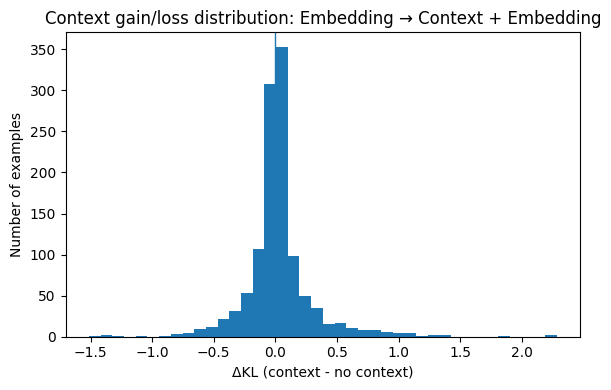

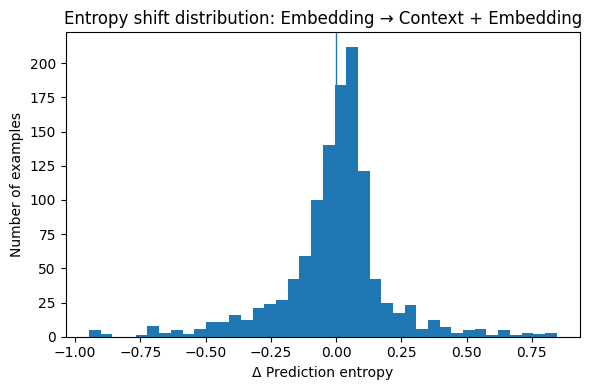

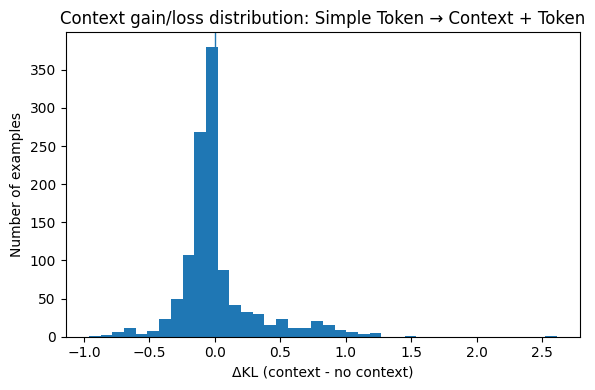

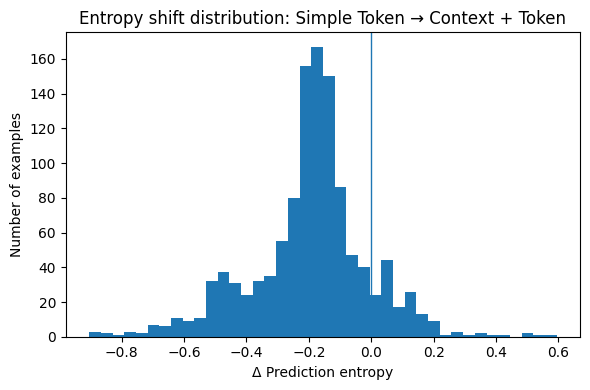

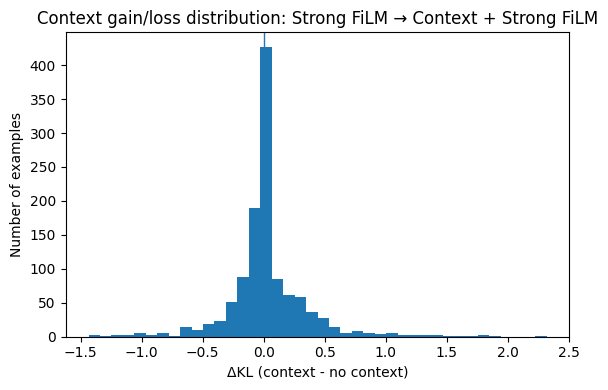

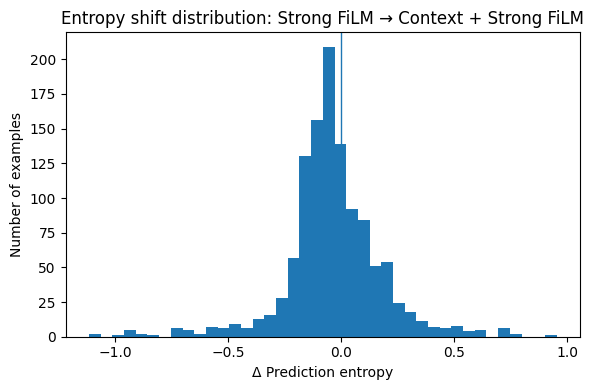

Saved context gain/loss histograms.


In [33]:
for pair, group in context_gain_df.groupby("pair"):
    safe_pair = pair.replace(" ", "_").replace("→", "to").replace("+", "plus")

    plt.figure(figsize=(6, 4))
    plt.hist(group["delta_kl"], bins=40)
    plt.axvline(0, linewidth=1)
    plt.xlabel("ΔKL (context - no context)")
    plt.ylabel("Number of examples")
    plt.title(f"Context gain/loss distribution: {pair}")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{safe_pair}_delta_kl_histogram.png", dpi=200)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(group["delta_pred_entropy"], bins=40)
    plt.axvline(0, linewidth=1)
    plt.xlabel("Δ Prediction entropy")
    plt.ylabel("Number of examples")
    plt.title(f"Entropy shift distribution: {pair}")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{safe_pair}_delta_entropy_histogram.png", dpi=200)
    plt.show()

print("Saved context gain/loss histograms.")


## 16H. Manual Coding Template for Context Gains and Harms

The quantitative analysis tells us **where** context helped or hurt.

This manual coding template is for qualitative interpretation.

Open:

```text
examples/largest_context_gains.csv
examples/largest_context_harms.csv
examples/most_context_sensitive_examples.csv
```

Then manually add one or more categories:

- explicit_slur
- direct_dehumanization
- women_policy
- national_identity
- religion
- race_or_ethnicity
- sarcasm_or_irony
- threat_or_violence
- personal_insult
- profanity_only
- ambiguous_context_needed
- context_misleading
- other

The goal is to produce a small table like:

| Category | Gains | Harms |
|---|---:|---:|
| explicit_slur |  |  |
| women_policy |  |  |
| sarcasm_or_irony |  |  |

This table is not automatic, but it will be very valuable in the Discussion chapter.


In [34]:
manual_coding_template = pd.DataFrame({
    "category": [
        "explicit_misogyny",
        "sexist_stereotype",
        "gender_role_norms",
        "patriarchy_or_power",
        "male_privilege",
        "violence_or_threat",
        "sexualisation_or_objectification",
        "harassment_or_abuse",
        "personal_insult",
        "profanity_only",
        "ambiguous_context_needed",
        "context_misleading",
        "other",
    ],
    "largest_gains_count": [np.nan] * 13,
    "largest_harms_count": [np.nan] * 13,
    "notes": [""] * 13,
})

manual_coding_template.to_csv(TABLES_DIR / "manual_context_example_coding_template.csv", index=False)
display(manual_coding_template)

print("Saved:", TABLES_DIR / "manual_context_example_coding_template.csv")


,category,largest_gains_count,largest_harms_count,notes
0,explicit_misogyny,NaN,NaN,
1,sexist_stereotype,NaN,NaN,
2,gender_role_norms,NaN,NaN,
3,patriarchy_or_power,NaN,NaN,
4,male_privilege,NaN,NaN,
5,violence_or_threat,NaN,NaN,
6,sexualisation_or_objectification,NaN,NaN,
7,harassment_or_abuse,NaN,NaN,
8,personal_insult,NaN,NaN,
9,profanity_only,NaN,NaN,


Saved: final_evaluation_outputs/women/tables/manual_context_example_coding_template.csv


## 17. Qualitative Examples

In [35]:
qualitative_frames = []

for model_name, df in predictions_by_model.items():
    best = df.sort_values("kl", ascending=True).head(5).copy()
    best["example_type"] = "best_lowest_kl"

    worst = df.sort_values("kl", ascending=False).head(5).copy()
    worst["example_type"] = "worst_highest_kl"

    qualitative_frames.extend([best, worst])

qualitative_examples_df = pd.concat(qualitative_frames, ignore_index=True)

keep_cols = [
    "model",
    "example_type",
    "comment_id",
    "subgroup",
    "text",
    "true_distribution",
    "pred_distribution",
    "target_majority_label",
    "pred_majority_label",
    "kl",
    "js",
    "cross_entropy",
    "true_anad",
]

qualitative_examples_df[keep_cols].to_csv(EXAMPLES_DIR / "qualitative_best_worst_examples.csv", index=False)

if not focus_pair_details_df.empty:
    tmp = focus_pair_details_df.copy()
    tmp["alignment_score"] = tmp["true_js"] * tmp["model_js"]
    tmp["spurious_score"] = tmp["model_js"] - tmp["true_js"]

    tmp.sort_values("alignment_score", ascending=False).head(30).to_csv(
        EXAMPLES_DIR / f"{FOCUS_PAIR_NAME}_human_aligned_examples.csv",
        index=False,
    )

    tmp.sort_values("spurious_score", ascending=False).head(30).to_csv(
        EXAMPLES_DIR / f"{FOCUS_PAIR_NAME}_spurious_disagreement_examples.csv",
        index=False,
    )

display(qualitative_examples_df[keep_cols].head(30))
print("Saved qualitative examples.")


,model,example_type,comment_id,subgroup,text,true_distribution,pred_distribution,target_majority_label,pred_majority_label,kl,js,cross_entropy,true_anad
0,Original A,best_lowest_kl,20054,men,oh that's cute. you didn't even read the thing you claim to support. there is nothing biologically inherent in women that would make them less adapt to do it work. thinking so does in fact make you 'crazy stupid'. sorry!,"[0.9456522, 0.02173913, 0.032608695]","[0.9335441, 0.03359368, 0.03286221]",0,0,0.002472,0.000952,0.250172,4.347826
1,Original A,best_lowest_kl,20055,men,There is plenty of evidence that women and non-white people are disadvantaged in almost every hiring process in the western world.,"[0.98892987, 0.003690037, 0.007380074]","[0.96861625, 0.016638726, 0.014745018]",0,0,0.009860,0.004196,0.077769,0.922509
2,Original A,best_lowest_kl,20032,women,shut the fuck up you dumb black bitch,"[0.18656716, 0.07462686, 0.73880595]","[0.25825024, 0.061876282, 0.67987347]",2,2,0.014738,0.005498,0.745305,22.388060
3,Original A,best_lowest_kl,20055,women,There is plenty of evidence that women and non-white people are disadvantaged in almost every hiring process in the western world.,"[0.99526066, 0.0047393367, 0.0]","[0.96861625, 0.016638726, 0.014745018]",0,0,0.021056,0.010034,0.051148,0.236967
4,Original A,best_lowest_kl,25681,women,A study shows that girls are fearing becoming leaders because of discrimination and violence. Our message must be that every girl has the potential to be leader. We have to empower every girls power. GenderEqualWorld. URL,"[1.0, 0.0, 0.0]","[0.9734135, 0.014031913, 0.012554595]",0,0,0.026946,0.013422,0.026946,0.000000
5,Original A,worst_highest_kl,6660,women,I know this is neither relevant to running or transition but reading your post just gave me insight to myself. I've got a medical disorder that causes me to have high testosterone for a woman. I've had it all my life. The funny thing is that I pr...,"[0.0, 0.0, 1.0]","[0.9609164, 0.021213926, 0.017869752]",2,0,4.024646,0.935116,4.024646,100.000000
6,Original A,worst_highest_kl,2389,men,I like the idea of killing babies but on the other hand I dont want women to have a choice.,"[0.0, 0.0, 1.0]","[0.95926136, 0.020946763, 0.019791871]",2,0,3.922484,0.929582,3.922484,100.000000
7,Original A,worst_highest_kl,2389,women,I like the idea of killing babies but on the other hand I dont want women to have a choice.,"[0.0, 1.0, 0.0]","[0.95926136, 0.020946763, 0.019791871]",1,0,3.865771,0.926322,3.865771,50.000000
8,Original A,worst_highest_kl,11994,women,Indian women deserve all the rape and female infanticide they get from Muslims in India,"[0.0, 0.0, 1.0]","[0.951307, 0.025868168, 0.022824781]",2,0,3.779908,0.921114,3.779908,100.000000
9,Original A,worst_highest_kl,6208,women,"Ah yes, all those 3rd wave feminist extremist mass shootings have begun to weigh heavily on the mind. When will it ever be safe to return to the outside, as a white man I am truly terrified ;_;","[0.0, 1.0, 0.0]","[0.9568617, 0.022971222, 0.020167146]",1,0,3.773513,0.920713,3.773513,50.000000


Saved qualitative examples.


## 18. Report-Ready Plots

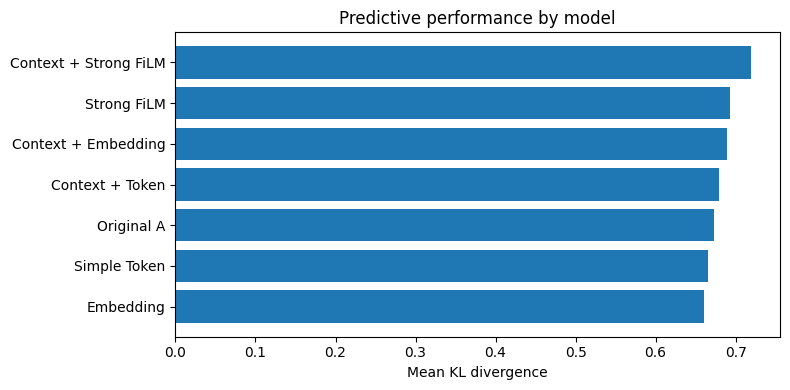

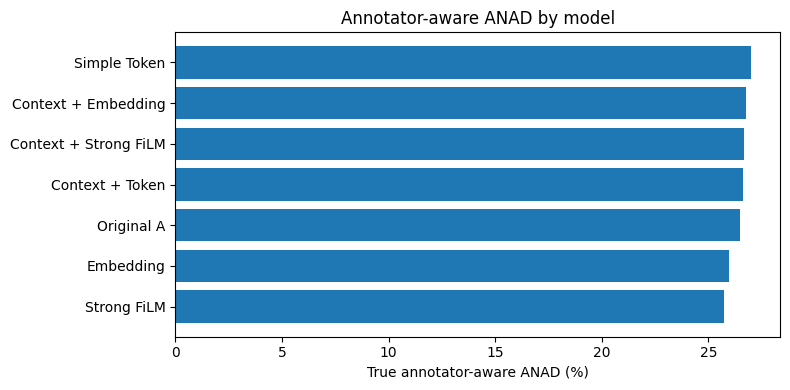

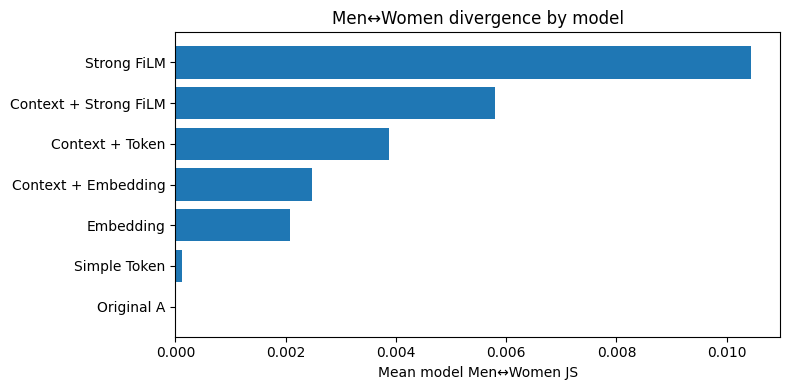

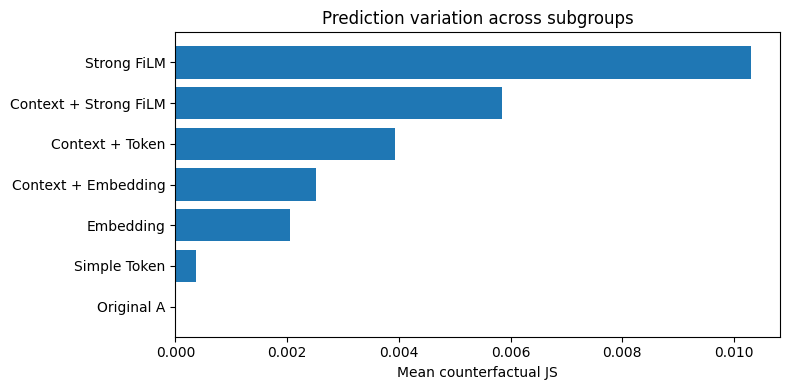

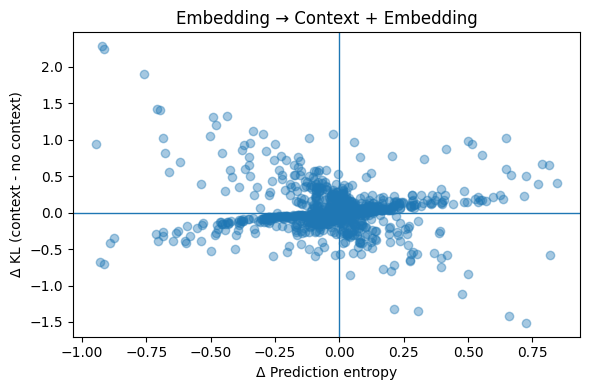

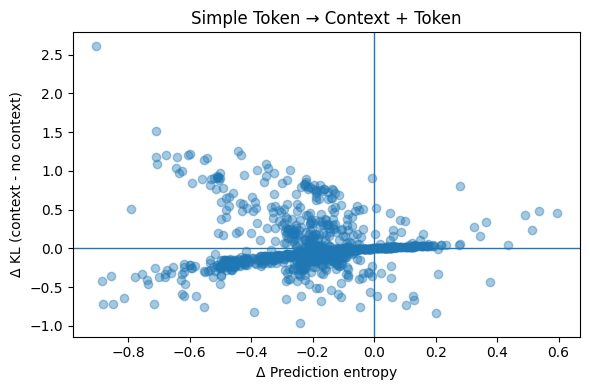

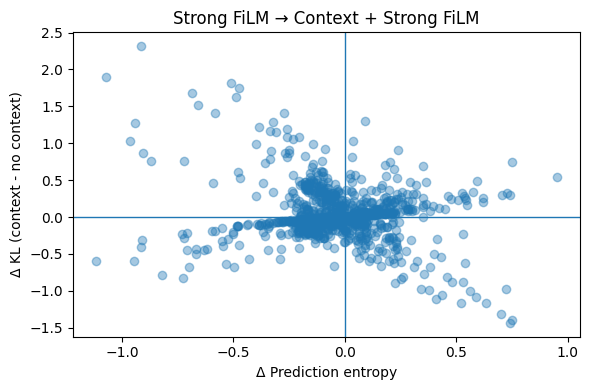

Saved plots to: final_evaluation_outputs/women/plots


In [36]:
plot_df = master_metrics_df.sort_values("kl_mean", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["kl_mean"])
plt.xlabel("Mean KL divergence")
plt.title("Predictive performance by model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "kl_by_model.png", dpi=200)
plt.show()

plot_df = master_metrics_df.sort_values("anad_mean", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["anad_mean"])
plt.xlabel("True annotator-aware ANAD (%)")
plt.title("Annotator-aware ANAD by model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "true_anad_by_model.png", dpi=200)
plt.show()

plot_df = focus_pair_summary_df.sort_values(f"mean_model_{FOCUS_PAIR_NAME}_js", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df[f"mean_model_{FOCUS_PAIR_NAME}_js"])
plt.xlabel(f"Mean model {FOCUS_PAIR_LABEL} JS")
plt.title(f"{FOCUS_PAIR_LABEL} divergence by model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{FOCUS_PAIR_NAME}_js_by_model.png", dpi=200)
plt.show()

plot_df = counterfactual_summary_df.sort_values("mean_counterfactual_js", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["mean_counterfactual_js"])
plt.xlabel("Mean counterfactual JS")
plt.title("Prediction variation across subgroups")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "counterfactual_js_by_model.png", dpi=200)
plt.show()

# Context entropy vs KL scatter
for pair, group in context_gain_df.groupby("pair"):
    plt.figure(figsize=(6, 4))
    plt.scatter(group["delta_pred_entropy"], group["delta_kl"], alpha=0.4)
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlabel("Δ Prediction entropy")
    plt.ylabel("Δ KL (context - no context)")
    plt.title(pair)
    plt.tight_layout()
    safe_pair = pair.replace(" ", "_").replace("→", "to").replace("+", "plus")
    plt.savefig(PLOTS_DIR / f"{safe_pair}_delta_entropy_vs_delta_kl.png", dpi=200)
    plt.show()

print("Saved plots to:", PLOTS_DIR)


## 19. Final Report Table

In [37]:
report_table = master_metrics_df.copy()

report_table = report_table.merge(
    counterfactual_summary_df[
        [
            "model",
            "mean_counterfactual_js",
            "median_counterfactual_js",
            "mean_max_pairwise_js",
            "median_max_pairwise_js",
        ]
    ],
    on="model",
    how="left",
)

report_table = report_table.merge(
    polarisation_summary_df[
        [
            "model",
            "mean_true_polarisation_js",
            "mean_model_polarisation_js",
            "mean_polarisation_error",
            "mean_abs_polarisation_error",
            "polarisation_capture_ratio",
            "spearman_true_vs_model_polarisation",
        ]
    ],
    on="model",
    how="left",
)

focus_cols = [
    "model",
    f"n_{FOCUS_PAIR_NAME}_pairs",
    f"mean_true_{FOCUS_PAIR_NAME}_js",
    f"mean_model_{FOCUS_PAIR_NAME}_js",
    f"median_model_{FOCUS_PAIR_NAME}_js",
    f"{FOCUS_PAIR_NAME}_capture_ratio",
]

report_table = report_table.merge(
    focus_pair_summary_df[focus_cols],
    on="model",
    how="left",
)

for col in [
    "mean_counterfactual_js",
    "median_counterfactual_js",
    "mean_max_pairwise_js",
    "median_max_pairwise_js",
    f"mean_model_{FOCUS_PAIR_NAME}_js",
    f"median_model_{FOCUS_PAIR_NAME}_js",
    f"{FOCUS_PAIR_NAME}_capture_ratio",
]:
    if col in report_table.columns:
        report_table.loc[report_table["model"] == "Original A", col] = (
            report_table.loc[report_table["model"] == "Original A", col].fillna(0.0)
        )

report_table = report_table.sort_values("kl_mean")
display(report_table)

report_table.to_csv(TABLES_DIR / "final_report_model_comparison.csv", index=False)
print("Saved:", TABLES_DIR / "final_report_model_comparison.csv")


,model,family,conditioning,uses_context,n,kl_mean,js_mean,cross_entropy_mean,distribution_mae_mean,accuracy,macro_f1,expected_label_mae,distribution_average_MD,average_wasserstein,mean_true_entropy,mean_pred_entropy,entropy_mae,entropy_median_abs_error,anad_mean,anad_median,anad_coverage,entropy_pearson,entropy_spearman,anad_subgroup_coverage,mean_counterfactual_js,median_counterfactual_js,mean_max_pairwise_js,median_max_pairwise_js,mean_true_polarisation_js,mean_model_polarisation_js,mean_polarisation_error,mean_abs_polarisation_error,polarisation_capture_ratio,spearman_true_vs_model_polarisation,n_men_women_pairs,mean_true_men_women_js,mean_model_men_women_js,median_model_men_women_js,men_women_capture_ratio
0,Embedding,embedding,gender_embedding,False,1173,0.660664,0.241478,0.744127,0.236024,0.705882,0.460117,0.551171,0.708071,0.580702,0.120412,0.869675,0.784499,0.831851,25.969483,0.0,1.0,0.136880,0.129569,1.0,2.047877e-03,0.002182,2.064363e-03,0.002226,0.344989,2.047877e-03,-0.342942,0.344707,5.936058e-03,0.342002,575,0.346507,2.084109e-03,0.002255,6.014625e-03
1,Simple Token,token,gender_as_text,False,1173,0.665467,0.259294,0.748931,0.258587,0.694800,0.454070,0.582427,0.775762,0.610560,0.120412,1.038095,0.942602,1.018009,27.013814,0.0,1.0,0.113414,0.113130,1.0,3.634084e-04,0.000010,3.986672e-04,0.000010,0.344989,3.634084e-04,-0.344626,0.344866,1.053390e-03,0.022741,575,0.346507,1.129810e-04,0.000009,3.260570e-04
2,Original A,comment_only,none,False,1173,0.672379,0.241955,0.755842,0.233916,0.701620,0.460010,0.551704,0.701749,0.578738,0.120412,0.834742,0.754475,0.710816,26.480992,0.0,1.0,0.138300,0.137102,1.0,1.975829e-18,0.000000,2.963744e-18,0.000000,0.344989,1.975829e-18,-0.344989,0.344989,5.727217e-18,0.033116,575,0.346507,2.999824e-18,0.000000,8.657331e-18
3,Context + Token,context_token,context_and_gender_as_text,True,1173,0.679814,0.243703,0.763277,0.235576,0.697357,0.458810,0.559666,0.706728,0.586552,0.120412,0.842520,0.763420,0.689772,26.608870,0.0,1.0,0.134485,0.120518,1.0,3.924584e-03,0.000226,3.931924e-03,0.000228,0.344989,3.924584e-03,-0.341065,0.344824,1.137595e-02,0.098685,575,0.346507,3.865133e-03,0.000225,1.115457e-02
4,Context + Embedding,context_embedding,context_text_plus_gender_embedding,True,1173,0.689133,0.247376,0.772596,0.239720,0.695652,0.460131,0.560432,0.719161,0.586165,0.120412,0.863508,0.785697,0.779824,26.765164,0.0,1.0,0.115072,0.101084,1.0,2.511902e-03,0.001557,2.528960e-03,0.001579,0.344989,2.511902e-03,-0.342478,0.344578,7.281099e-03,0.186297,575,0.346507,2.473670e-03,0.001574,7.138878e-03
5,Strong FiLM,film,film_gender_modulation,False,1173,0.692755,0.243159,0.776218,0.232976,0.710145,0.465231,0.548156,0.698929,0.574906,0.120412,0.822072,0.748929,0.629357,25.727938,0.0,1.0,0.137086,0.127451,1.0,1.030741e-02,0.010894,1.037575e-02,0.010974,0.344989,1.030741e-02,-0.334682,0.343845,2.987746e-02,0.300698,575,0.346507,1.044541e-02,0.011067,3.014489e-02
6,Context + Strong FiLM,context_film,context_text_plus_film_gender_modulation,True,1173,0.719503,0.244934,0.802966,0.231794,0.702472,0.458404,0.540895,0.695382,0.562956,0.120412,0.783496,0.719219,0.618153,26.658600,0.0,1.0,0.118648,0.117159,1.0,5.837839e-03,0.004135,5.890218e-03,0.004135,0.344989,5.837839e-03,-0.339152,0.344098,1.692179e-02,0.248011,575,0.346507,5.805718e-03,0.004155,1.675499e-02


Saved: final_evaluation_outputs/women/tables/final_report_model_comparison.csv


## 20. Auto-Generated Findings Skeleton

In [38]:
print("=" * 100)
print("AUTO-GENERATED FINDINGS SKELETON")
print("=" * 100)

best_kl = master_metrics_df.sort_values("kl_mean").iloc[0]
best_js = master_metrics_df.sort_values("js_mean").iloc[0]
best_f1 = master_metrics_df.sort_values("macro_f1", ascending=False).iloc[0]
best_anad = master_metrics_df.sort_values("anad_mean").iloc[0]

print(f"1. Best KL model: {best_kl['model']} (KL={best_kl['kl_mean']:.4f}).")
print(f"2. Best JS model: {best_js['model']} (JS={best_js['js_mean']:.4f}).")
print(f"3. Best Macro F1 model: {best_f1['model']} (Macro F1={best_f1['macro_f1']:.4f}).")
print(f"4. Best ANAD model: {best_anad['model']} (ANAD={best_anad['anad_mean']:.2f}%).")

if not counterfactual_summary_df.empty:
    best_cf = counterfactual_summary_df.sort_values("mean_counterfactual_js", ascending=False).iloc[0]
    print(f"5. Highest counterfactual subgroup variation: {best_cf['model']} (mean JS={best_cf['mean_counterfactual_js']:.6f}).")

if not polarisation_summary_df.empty:
    best_pol = polarisation_summary_df.sort_values("mean_abs_polarisation_error").iloc[0]
    print(f"6. Closest polarisation index: {best_pol['model']} (abs error={best_pol['mean_abs_polarisation_error']:.6f}).")

if not focus_pair_summary_df.empty:
    best_focus = focus_pair_summary_df.sort_values(f"mean_model_{FOCUS_PAIR_NAME}_js", ascending=False).iloc[0]
    print(f"7. Highest {FOCUS_PAIR_LABEL} predicted divergence: {best_focus['model']} (JS={best_focus[f'mean_model_{FOCUS_PAIR_NAME}_js']:.6f}).")

print("\nContext matched-pair effects:")
for _, row in context_pair_effects_df.iterrows():
    direction = "improved" if row["delta_kl"] < 0 else "worsened"
    print(f" - {row['pair']}: KL {direction} by {row['delta_kl']:.4f}.")

print("\nSafe discussion claim template:")
print("Aggregate metrics alone may not fully describe the effect of context.")
print("Use subgroup metrics, polarisation, counterfactual variation, focus-pair divergence, and example-level shifts to explain behavioural changes.")
print("Do not claim context is beneficial unless supported by the corresponding table.")


AUTO-GENERATED FINDINGS SKELETON
1. Best KL model: Embedding (KL=0.6607).
2. Best JS model: Embedding (JS=0.2415).
3. Best Macro F1 model: Strong FiLM (Macro F1=0.4652).
4. Best ANAD model: Strong FiLM (ANAD=25.73%).
5. Highest counterfactual subgroup variation: Strong FiLM (mean JS=0.010307).
6. Closest polarisation index: Strong FiLM (abs error=0.343845).
7. Highest Men↔Women predicted divergence: Strong FiLM (JS=0.010445).

Context matched-pair effects:
 - Simple Token → Context + Token: KL worsened by 0.0143.
 - Embedding → Context + Embedding: KL worsened by 0.0285.
 - Strong FiLM → Context + Strong FiLM: KL worsened by 0.0267.

Safe discussion claim template:
Aggregate metrics alone may not fully describe the effect of context.
Use subgroup metrics, polarisation, counterfactual variation, focus-pair divergence, and example-level shifts to explain behavioural changes.
Do not claim context is beneficial unless supported by the corresponding table.
